# 🪙 Crypto Price Predictor — LSTM Puro + Series Temporales

**Flujo completo:**
1. Actualiza datos raw hasta hoy
2. 📊 **Análisis de Series Temporales**
3. Construye features reducidas (sin ruido)
4. Entrena LSTM puro con atención
5. Backtesting con comisiones reales
6. Inferencia con intervalos de confianza

> **GPU T4** activado en Settings → Accelerator  

In [1]:
!pip install torch pandas numpy scikit-learn matplotlib statsmodels gymnasium stable-baselines3 shimmy sb3-contrib --quiet

# !pip install torch pandas numpy scikit-learn matplotlib statsmodels gymnasium stable-baselines3 shimmy --quiet

import os, math, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import requests
from datetime import datetime, timezone

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

RAW_DIR    = "/kaggle/input/datasets/vicentelorenzomarn/dataraw"
WORK_DIR   = "/kaggle/working"
MODELS_DIR = "/kaggle/input/datasets/vicentelorenzomarn/crypto-models"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs("plots", exist_ok=True)

MAPE_HISTORICO = {
    "BTC":  0.0055, "ETH":  0.0091, "SOL":  0.0101,
    "AVAX": 0.0106,
}
UMBRALES_BT = {
    "BTC": 0.003, "ETH": 0.003, "SOL": 0.003,
    "AVAX": 0.003,
}

# ──────────────────────────────────────────────────────────────
# FEATURE_COLS
# ──────────────────────────────────────────────────────────────
FEATURE_COLS = [
    "close","volume","return_1","return_7",
    "rsi_14","macd","macd_signal","bb_position",
    "bb_width","atr_14","volume_ratio","hour_sin",
    "hour_cos","dow_sin","dow_cos","fear_greed",
    "return_4h","rsi_4h","return_1d","rsi_1d",
]

print(f"Features → {len(FEATURE_COLS)}")

BASE_CONFIG = {
    "data_dir":        WORK_DIR,
    "raw_dir":         RAW_DIR,
    "coins":           ["BTC", "ETH", "SOL", "AVAX"],
    "granularity":     "hourly",
    "horizons":        [1, 2, 3, 4],
    "horizon_weights": [1.0, 0.85, 0.70, 0.55],
    "train_ratio":     0.70,
    "val_ratio":       0.15,
    "feature_cols":    FEATURE_COLS,
    "epochs":          150,
    "patience":        20,
    "wf_folds":        5,
}

# Configs por moneda — solo parámetros LSTM
BEST_CONFIGS = {
    "BTC": {**BASE_CONFIG, **{
        "lstm_hidden":    256, "lstm_layers":    2,
        "lstm_dropout":   0.145, "head_dropout":   0.275,
        "head_hidden":    64, "seq_len":        24,
        "batch_size":     64, "learning_rate":  0.00174,
        "weight_decay":   0.0327,
    }},
    "ETH": {**BASE_CONFIG, **{
    "lstm_hidden":    64, "lstm_layers":    3,
    "lstm_dropout":   0.134, "head_dropout":   0.284,
    "head_hidden":    64, "seq_len":        24,
    "batch_size":     32, "learning_rate":  0.00172,  # 1.72e-03
    "weight_decay":   0.00139,
}},
    "SOL": {**BASE_CONFIG, **{
        "lstm_hidden": 256, "lstm_layers": 2,
        "lstm_dropout": 0.29, "head_dropout": 0.24,
        "head_hidden": 64, "seq_len": 24, "batch_size": 128,
        "learning_rate": 0.000190, "weight_decay": 0.000436,
    }},
    "AVAX": {**BASE_CONFIG, **{
        "lstm_hidden": 128, "lstm_layers": 2,
        "lstm_dropout": 0.32, "head_dropout": 0.13,
        "head_hidden": 32, "seq_len": 48, "batch_size": 128,
        "learning_rate": 0.000286, "weight_decay": 0.00324,
    }},
}

print("✅ Configuración cargada.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 8.9 MB/s eta 0:00:00
Dispositivo: cuda
GPU: Tesla T4
Features → 20
✅ Configuración cargada.


# 📥 Descarga y Actualización de Datos

In [2]:
COINS_MAP = {
    "BTC": "BTCUSDT", "ETH": "ETHUSDT", "SOL": "SOLUSDT",
    "AVAX": "AVAXUSDT",
}
START_DATES = {
    "BTC": "2020-01-01", "ETH": "2020-01-01", "SOL": "2020-09-01",
    "AVAX": "2020-10-01",
}
BINANCE_URLS = [
    "https://api.binance.us/api/v3/klines",
    "https://api.binance.com/api/v3/klines",
]

def _date_to_ms(date_str):
    return int(datetime.strptime(date_str, "%Y-%m-%d")
               .replace(tzinfo=timezone.utc).timestamp() * 1000)

def binance_get(params, timeout=15):
    for url in BINANCE_URLS:
        try:
            r = requests.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            return r.json()
        except Exception:
            continue
    return None

def download_historical(symbol, interval, start_date):
    start_ms = _date_to_ms(start_date)
    end_ms   = int(datetime.now(timezone.utc).timestamp() * 1000)
    rows     = []
    while start_ms < end_ms:
        batch = binance_get({"symbol": symbol, "interval": interval,
                              "startTime": start_ms, "limit": 1000})
        if not batch: break
        for c in batch:
            rows.append({"timestamp": pd.to_datetime(c[0], unit="ms", utc=True),
                          "open": float(c[1]), "high": float(c[2]),
                          "low":  float(c[3]), "close": float(c[4]),
                          "volume": float(c[5])})
        start_ms = batch[-1][0] + 1
        time.sleep(0.15)
    if not rows: return None
    return (pd.DataFrame(rows).drop_duplicates("timestamp")
              .sort_values("timestamp").reset_index(drop=True))

def download_recent(symbol, interval, limit=500):
    batch = binance_get({"symbol": symbol, "interval": interval, "limit": limit})
    if not batch: return None
    rows = [{"timestamp": pd.to_datetime(c[0], unit="ms", utc=True),
             "open": float(c[1]), "high": float(c[2]),
             "low":  float(c[3]), "close": float(c[4]),
             "volume": float(c[5])} for c in batch]
    return (pd.DataFrame(rows).drop_duplicates("timestamp")
              .sort_values("timestamp").reset_index(drop=True))

def update_raw_csv(path, symbol, interval, start_date, coin):
    if os.path.exists(path):
        df_existing = pd.read_csv(path, parse_dates=["timestamp"])
        if df_existing["timestamp"].dt.tz is None:
            df_existing["timestamp"] = df_existing["timestamp"].dt.tz_localize("UTC")
        last_ts = df_existing["timestamp"].max()
        df_new = download_recent(symbol, interval, limit=1000)
        if df_new is not None:
            if df_new["timestamp"].dt.tz is None:
                df_new["timestamp"] = df_new["timestamp"].dt.tz_localize("UTC")
            df_new = df_new[df_new["timestamp"] > last_ts]
        if df_new is None or len(df_new) == 0:
            print(f"  {coin} {interval}: ya actualizado ({last_ts.date()}) ✅")
            return
        df_new["coin"] = coin
        df_updated = (pd.concat([df_existing, df_new], ignore_index=True)
                        .drop_duplicates("timestamp")
                        .sort_values("timestamp").reset_index(drop=True))
        df_updated.to_csv(path, index=False)
        print(f"  {coin} {interval}: +{len(df_new)} velas → hasta {df_updated['timestamp'].max().date()} ✅")
    else:
        src_candidates = [
            f"{RAW_DIR}/{coin}_{interval}_raw.csv",
            f"{RAW_DIR}/{coin}_hourly_raw.csv" if interval == "1h" else None,
        ]
        copied = False
        for src in src_candidates:
            if src and os.path.exists(src):
                df = pd.read_csv(src, parse_dates=["timestamp"])
                if df["timestamp"].dt.tz is None:
                    df["timestamp"] = df["timestamp"].dt.tz_localize("UTC")
                df["coin"] = coin
                df.to_csv(path, index=False)
                print(f"  {coin} {interval}: copiado desde dataset ✅")
                copied = True
                update_raw_csv(path, symbol, interval, start_date, coin)
                break
        if copied: return
        df = download_historical(symbol, interval, start_date)
        if df is not None:
            df["coin"] = coin
            df.to_csv(path, index=False)
            print(f"{len(df):,} velas → hasta {df['timestamp'].max().date()} ✅")
        else:
            print("✗ no disponible")

def ensure_and_update_all(work_dir):
    print("\n── Actualizando datos raw ──────────────────────────────────")
    for coin, symbol in COINS_MAP.items():
        for interval in ["1h", "4h", "1d"]:
            path = f"{work_dir}/{coin}_{interval}_raw.csv"
            update_raw_csv(path, symbol, interval, START_DATES[coin], coin)
    print("✅ Datos raw actualizados.\n")

# ensure_and_update_all(WORK_DIR)

# 📊 Análisis de Series Temporales

In [3]:
# ═══════════════════════════════════════════════════════════════════
# ANÁLISIS DE SERIES TEMPORALES — Ejecutar tras descargar datos raw
# ═══════════════════════════════════════════════════════════════════

def load_raw_for_analysis(coin, raw_dir):
    path = f"{raw_dir}/{coin}_1h_raw.csv"
    df = pd.read_csv(path, parse_dates=["timestamp"]).sort_values("timestamp")
    df["return"] = df["close"].pct_change()
    df = df.dropna().reset_index(drop=True)
    return df


# ─── 1. TEST DE ESTACIONARIEDAD (Dickey-Fuller Aumentado) ─────────────────
def test_stationarity(series, name="Serie"):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"  {name}")
    print(f"    ADF Statistic : {result[0]:.4f}")
    print(f"    p-value       : {result[1]:.6f}  {'✅ ESTACIONARIA' if result[1] < 0.05 else '❌ NO ESTACIONARIA (tendencia/raíz unitaria)'}")
    print(f"    Lags usados   : {result[2]}")
    print()
    return result[1] < 0.05

def run_stationarity_analysis(coins, raw_dir):
    print("\n" + "="*65)
    print("  TEST DE ESTACIONARIEDAD (ADF) — Precio vs Retorno")
    print("="*65 + "\n")
    for coin in coins:
        try:
            df = load_raw_for_analysis(coin, raw_dir)
            print(f"─── {coin} ───────────────────────────────────────")
            test_stationarity(df["close"].tail(5000),  f"Precio cierre (últimas 5000h)")
            test_stationarity(df["return"].tail(5000), f"Retorno (pct_change)")
        except FileNotFoundError:
            print(f"  {coin}: archivo no encontrado, omitiendo")

run_stationarity_analysis(BASE_CONFIG["coins"], RAW_DIR)


  TEST DE ESTACIONARIEDAD (ADF) — Precio vs Retorno

─── BTC ───────────────────────────────────────
  Precio cierre (últimas 5000h)
    ADF Statistic : -2.5781
    p-value       : 0.097617  ❌ NO ESTACIONARIA (tendencia/raíz unitaria)
    Lags usados   : 6

  Retorno (pct_change)
    ADF Statistic : -69.9438
    p-value       : 0.000000  ✅ ESTACIONARIA
    Lags usados   : 0

─── ETH ───────────────────────────────────────
  Precio cierre (últimas 5000h)
    ADF Statistic : -2.4681
    p-value       : 0.123424  ❌ NO ESTACIONARIA (tendencia/raíz unitaria)
    Lags usados   : 6

  Retorno (pct_change)
    ADF Statistic : -68.5583
    p-value       : 0.000000  ✅ ESTACIONARIA
    Lags usados   : 0

─── SOL ───────────────────────────────────────
  Precio cierre (últimas 5000h)
    ADF Statistic : -2.6166
    p-value       : 0.089608  ❌ NO ESTACIONARIA (tendencia/raíz unitaria)
    Lags usados   : 31

  Retorno (pct_change)
    ADF Statistic : -28.5020
    p-value       : 0.000000  ✅ ESTACI


Generando gráficos ACF/PACF


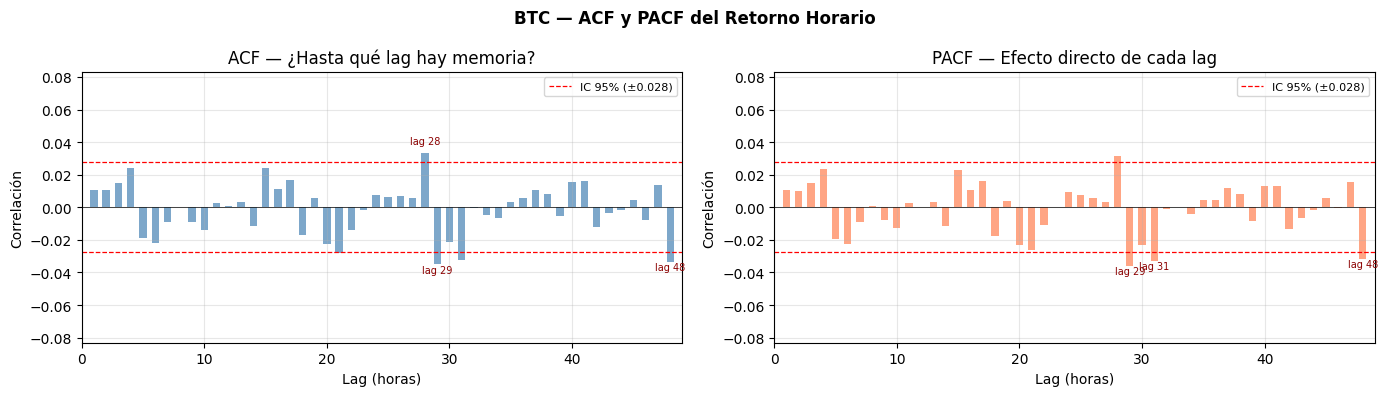

  BTC: ACF/PACF guardado ✅


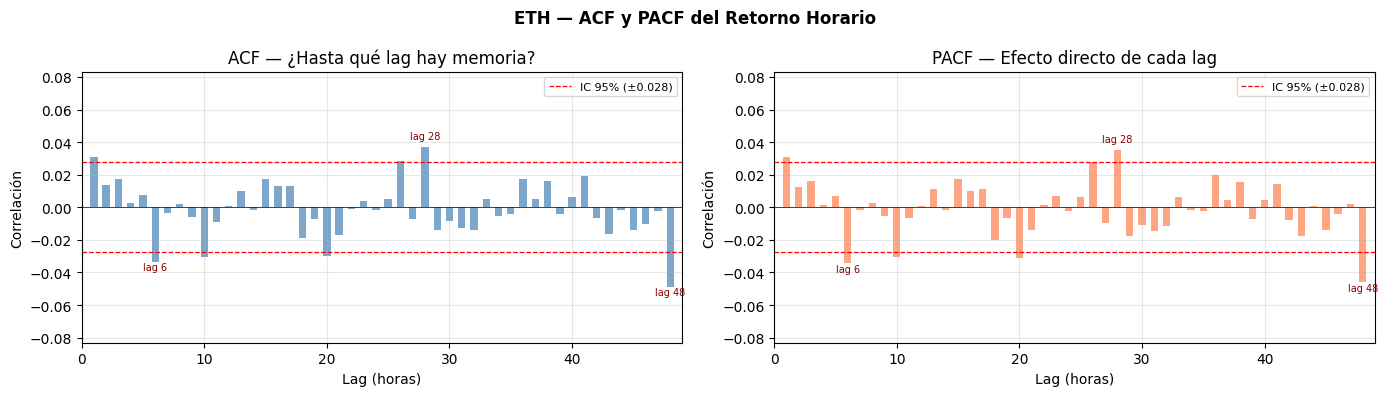

  ETH: ACF/PACF guardado ✅


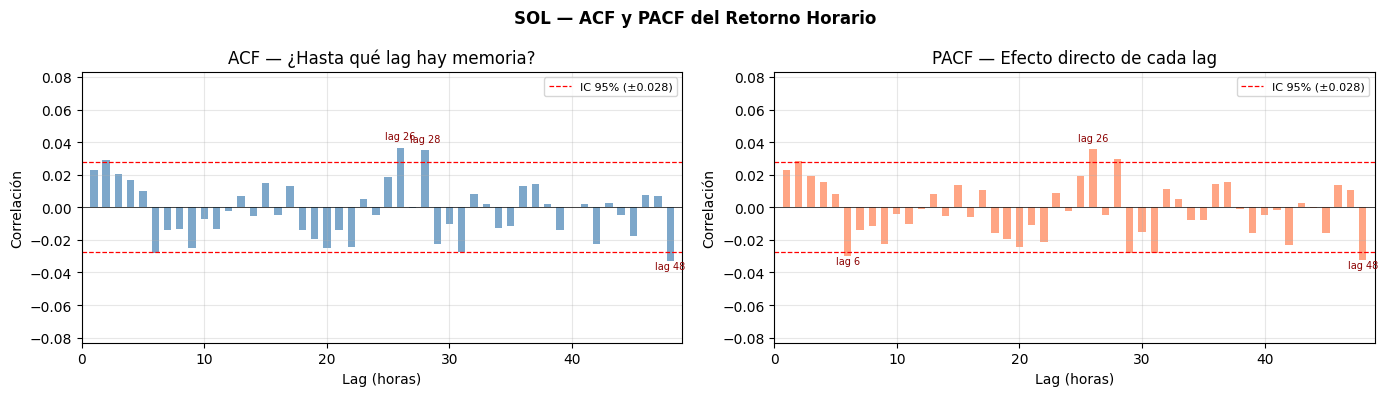

  SOL: ACF/PACF guardado ✅


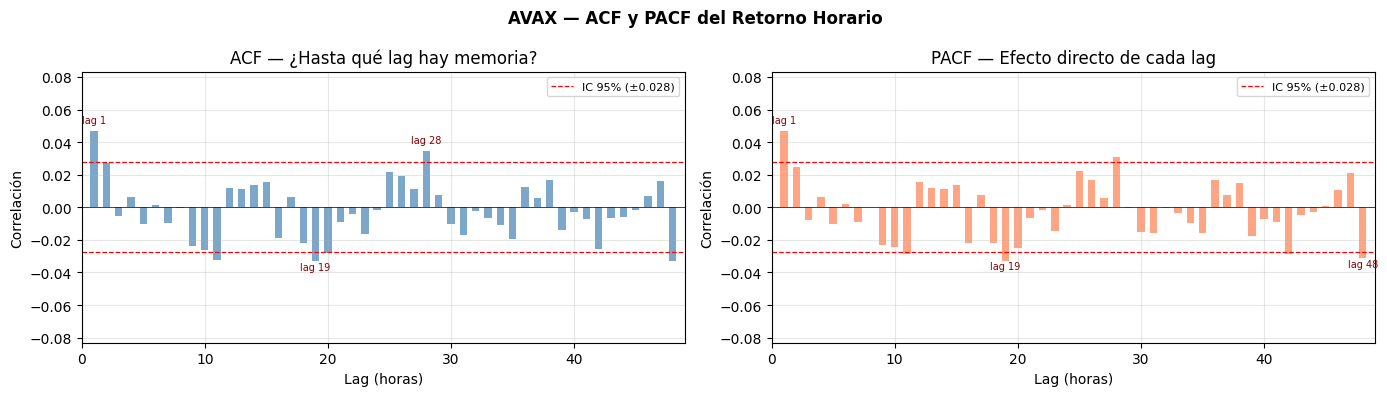

  AVAX: ACF/PACF guardado ✅


In [4]:
# ─── 2. AUTOCORRELACIÓN (ACF) y AUTOCORRELACIÓN PARCIAL (PACF) ───────────
def plot_acf_pacf(coin, raw_dir, lags=48, col="return"):
    try:
        df = load_raw_for_analysis(coin, raw_dir)
        series = df[col].tail(5000).dropna().values

        acf_vals  = acf(series,  nlags=lags, fft=True)
        pacf_vals = pacf(series, nlags=lags, method="ywm")
        ci = 1.96 / np.sqrt(len(series))   # Intervalo de confianza 95%

        lags_x    = np.arange(1, lags + 1)
        acf_plot  = acf_vals[1:]
        pacf_plot = pacf_vals[1:]

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f"{coin} — ACF y PACF del Retorno Horario",
                     fontsize=12, fontweight="bold")

        for ax, vals, title, color in [
            (axes[0], acf_plot,  "ACF — ¿Hasta qué lag hay memoria?",       "steelblue"),
            (axes[1], pacf_plot, "PACF — Efecto directo de cada lag",        "coral"),
        ]:
            ax.bar(lags_x, vals, color=color, alpha=0.7, width=0.6)
            ax.axhline( ci, color="red", linestyle="--", linewidth=0.9, label=f"IC 95% (±{ci:.3f})")
            ax.axhline(-ci, color="red", linestyle="--", linewidth=0.9)
            ax.axhline( 0,  color="black", linewidth=0.5)
            ax.set_xlim(0, lags + 1)
            # Limitar eje Y para que las barras pequeñas se vean bien
            max_visible = max(np.abs(vals).max() * 1.3, ci * 3)
            ax.set_ylim(-max_visible, max_visible)
            ax.set_title(title)
            ax.set_xlabel("Lag (horas)")
            ax.set_ylabel("Correlación")
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)

            # Anotar los 3 lags con mayor correlación absoluta
            top3_idx = np.argsort(np.abs(vals))[-3:][::-1]
            for idx in top3_idx:
                if abs(vals[idx]) > ci:
                    ax.annotate(f"lag {lags_x[idx]}",
                                xy=(lags_x[idx], vals[idx]),
                                xytext=(0, 6 * np.sign(vals[idx])),
                                textcoords="offset points",
                                ha="center", fontsize=7, color="darkred")

        plt.tight_layout()
        plt.savefig(f"plots/{coin}_acf_pacf.png", dpi=120, bbox_inches="tight")
        plt.show()
        print(f"  {coin}: ACF/PACF guardado ✅")
    except FileNotFoundError:
        print(f"  {coin}: archivo no encontrado")

print("\nGenerando gráficos ACF/PACF")
for coin in BASE_CONFIG["coins"]:
    plot_acf_pacf(coin, RAW_DIR)


Descomponiendo series temporales...


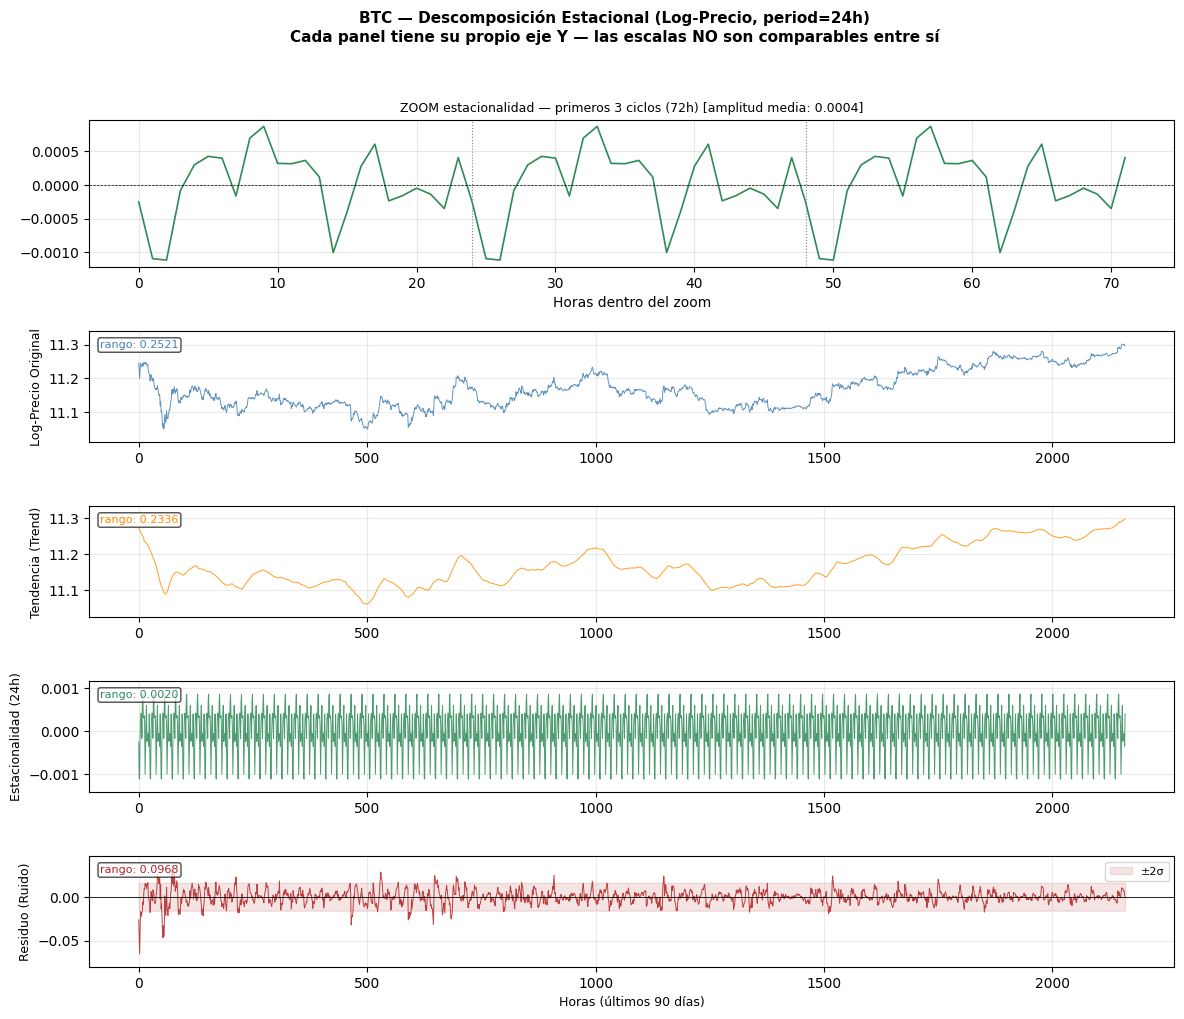

  BTC: descomposición guardada ✅


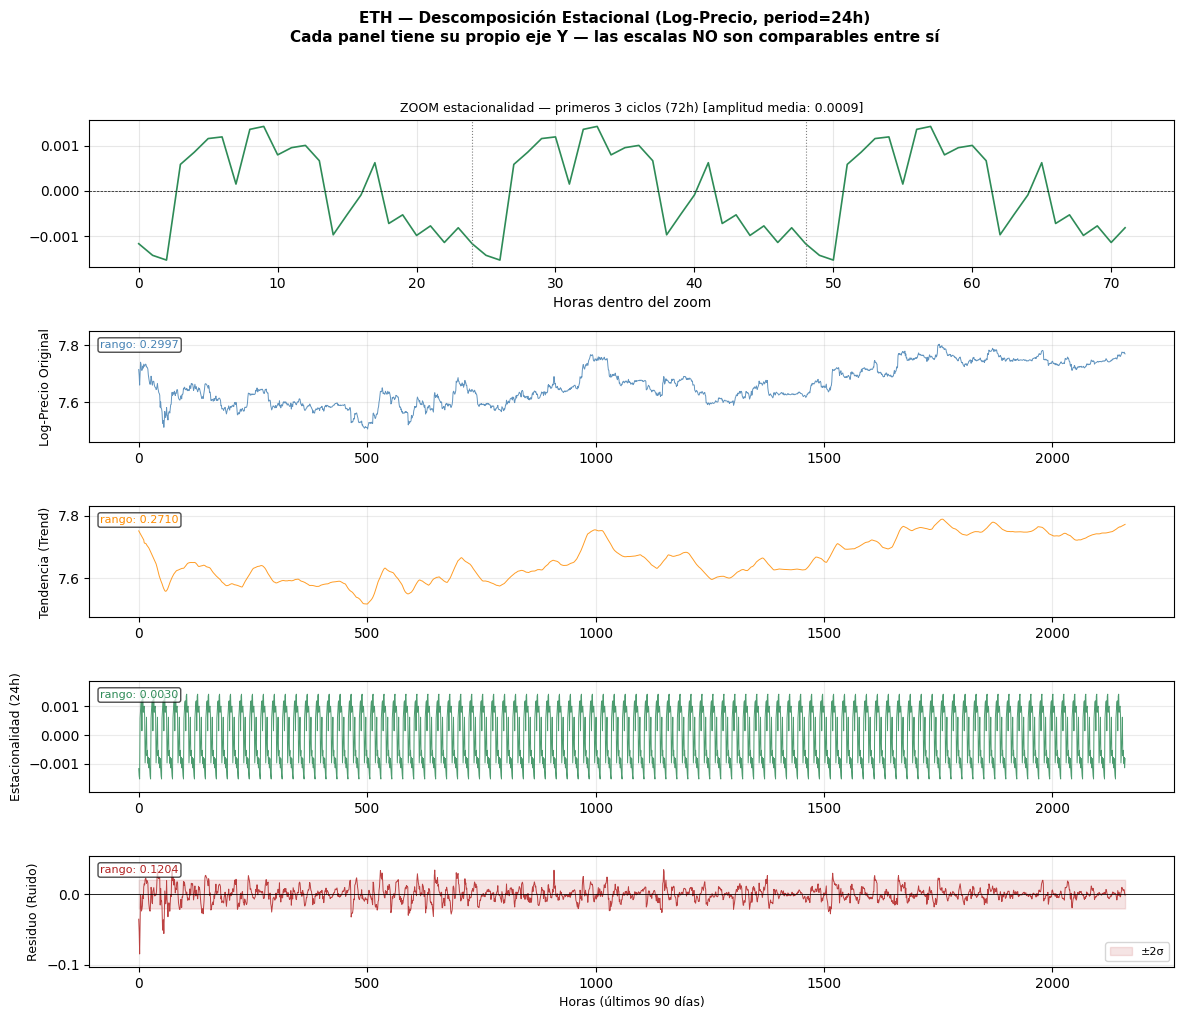

  ETH: descomposición guardada ✅


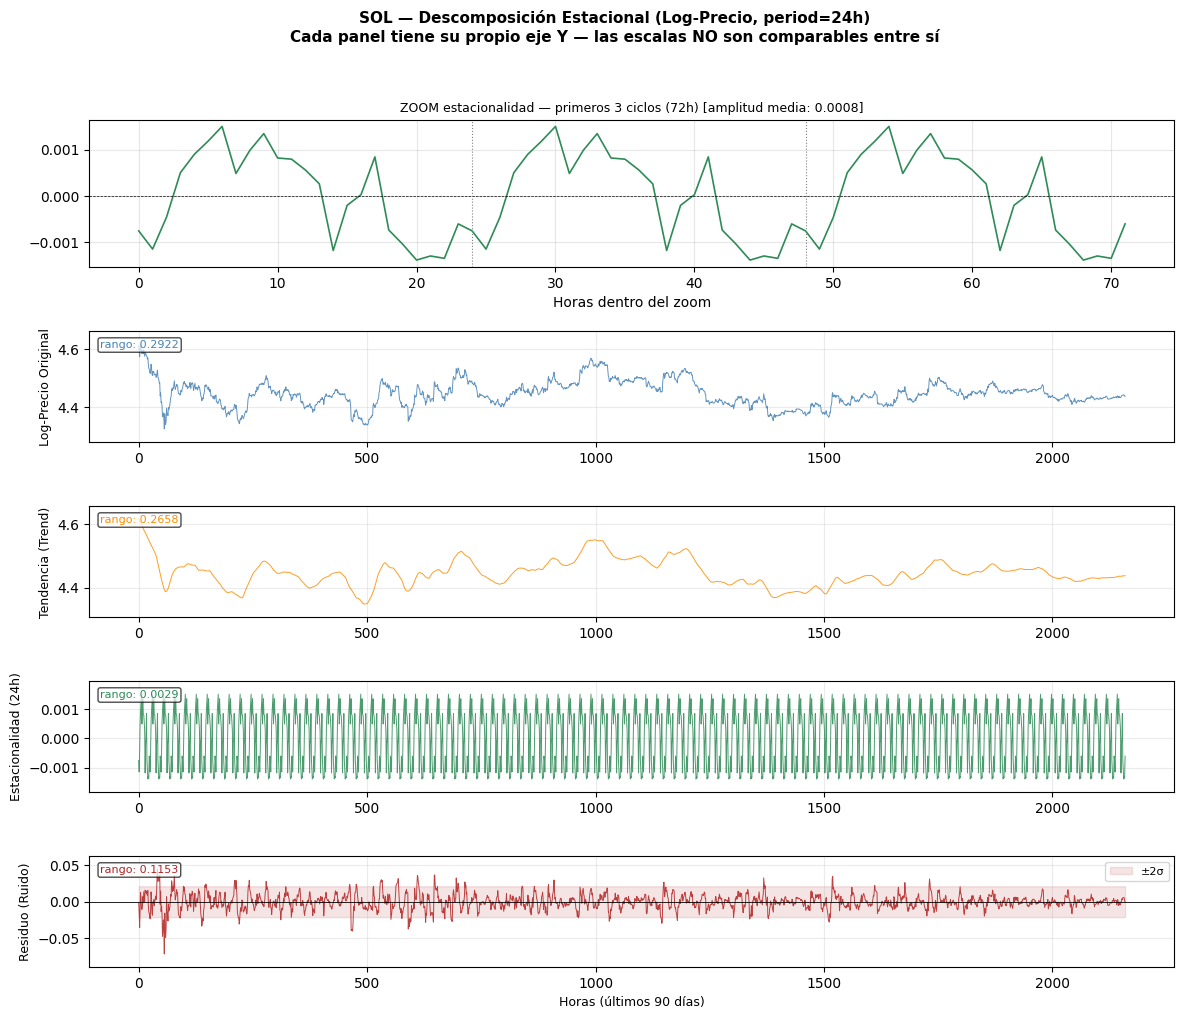

  SOL: descomposición guardada ✅


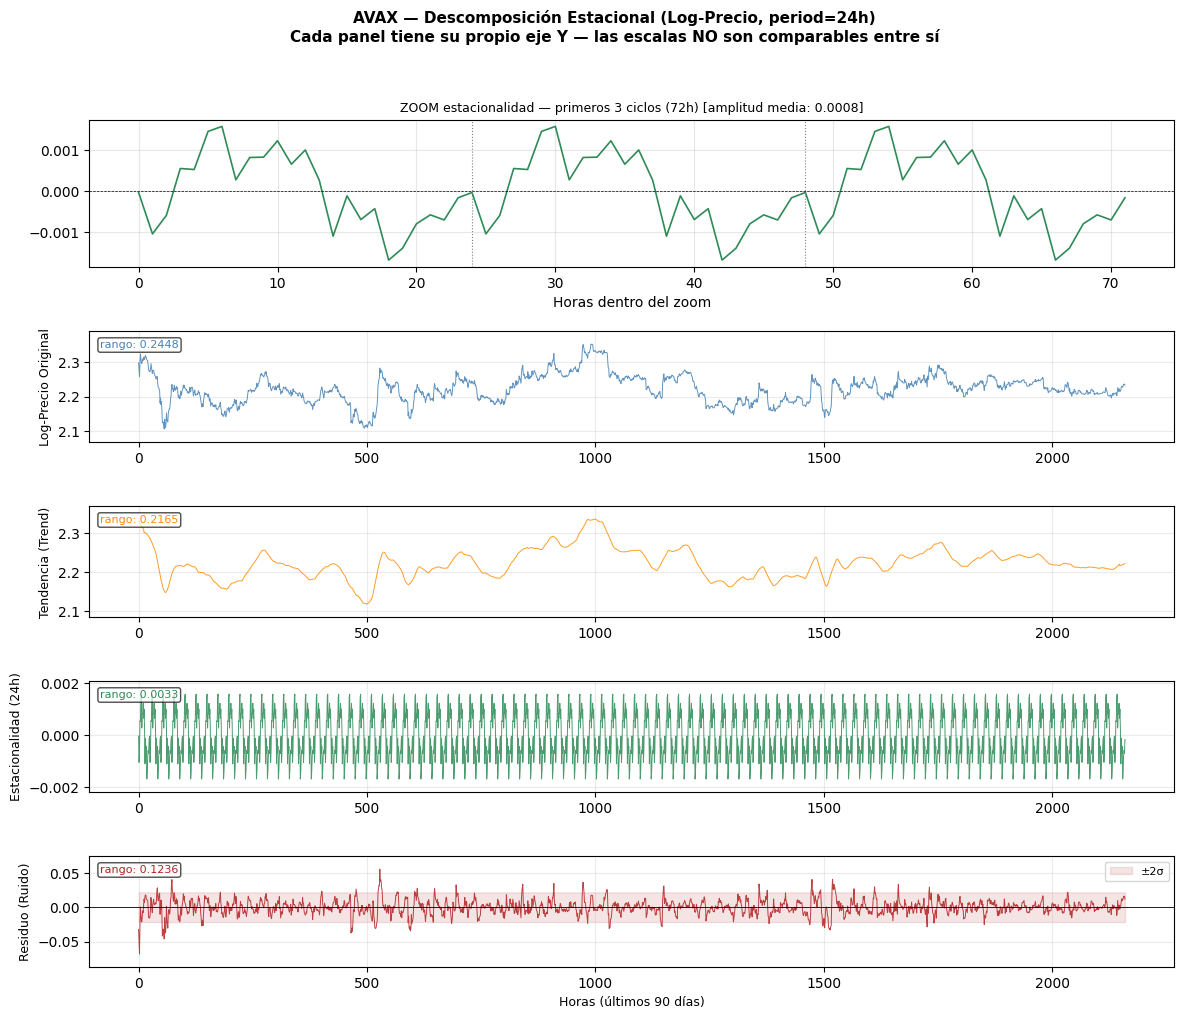

  AVAX: descomposición guardada ✅


In [5]:
# ─── 3. DESCOMPOSICIÓN ESTACIONAL ─────────────────────────────────────────
def plot_decomposition(coin, raw_dir, period=24):
    try:
        df = load_raw_for_analysis(coin, raw_dir)
        log_price = np.log(df["close"].tail(24 * 90))
        log_price.index = pd.RangeIndex(len(log_price))

        result = seasonal_decompose(log_price, model="additive",
                                    period=period, extrapolate_trend="freq")

        fig = plt.figure(figsize=(14, 11))
        fig.suptitle(
            f"{coin} — Descomposición Estacional (Log-Precio, period={period}h)\n"
            f"Cada panel tiene su propio eje Y — las escalas NO son comparables entre sí",
            fontsize=11, fontweight="bold"
        )
        gs = fig.add_gridspec(5, 1, hspace=0.55, height_ratios=[1.6, 1.2, 1.2, 1.2, 1.2])

        # ── Panel zoom estacional (fila 0) ────────────────────────────
        ax_zoom = fig.add_subplot(gs[0])
        seasonal_zoom = result.seasonal.iloc[:3 * period].dropna()
        ax_zoom.plot(seasonal_zoom.values, color="seagreen", linewidth=1.2)
        ax_zoom.axhline(0, color="black", linewidth=0.5, linestyle="--")
        ax_zoom.set_title(
            f"ZOOM estacionalidad — primeros 3 ciclos ({3*period}h) "
            f"[amplitud media: {seasonal_zoom.abs().mean():.4f}]",
            fontsize=9
        )
        ax_zoom.set_xlabel("Horas dentro del zoom")
        ax_zoom.grid(alpha=0.3)
        for p_ in range(1, 3):
            ax_zoom.axvline(p_ * period, color="gray", linestyle=":", linewidth=0.8)

        # ── Paneles de componentes (filas 1-4) ───────────────────────
        components = [
            (log_price,       "Log-Precio Original",          "steelblue"),
            (result.trend,    "Tendencia (Trend)",             "darkorange"),
            (result.seasonal, f"Estacionalidad ({period}h)",   "seagreen"),
            (result.resid,    "Residuo (Ruido)",                "firebrick"),
        ]

        ax_last = None
        for row, (comp, label, color) in enumerate(components):
            ax = fig.add_subplot(gs[row + 1])
            ax_last = ax
            clean = comp.dropna()
            ax.plot(clean.index, clean.values, color=color, linewidth=0.7, alpha=0.85)
            rng = clean.values.max() - clean.values.min()
            pad = rng * 0.15 if rng > 0 else 0.001
            ax.set_ylim(clean.values.min() - pad, clean.values.max() + pad)
            ax.set_ylabel(label, fontsize=9)
            ax.grid(alpha=0.25)

            if "Residuo" in label:
                σ = clean.std()
                ax.axhline(0, color="black", linewidth=0.6)
                ax.fill_between(clean.index, -2*σ, 2*σ,
                                alpha=0.12, color="firebrick", label="±2σ")
                ax.legend(fontsize=8)

            ax.annotate(f"rango: {rng:.4f}",
                        xy=(0.01, 0.85), xycoords="axes fraction",
                        fontsize=8, color=color,
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

        ax_last.set_xlabel("Horas (últimos 90 días)", fontsize=9)

        plt.savefig(f"plots/{coin}_decomposition.png", dpi=120, bbox_inches="tight")
        plt.show()
        print(f"  {coin}: descomposición guardada ✅")
    except FileNotFoundError:
        print(f"  {coin}: archivo no encontrado")
    except Exception as e:
        print(f"  {coin}: error en descomposición ({e})")

print("\nDescomponiendo series temporales...")
for coin in BASE_CONFIG["coins"]:
    plot_decomposition(coin, RAW_DIR)

# 🌐 Datos Externos: Fear & Greed + Dominancia BTC

In [6]:
def download_fear_greed(limit=2000, verbose=False):
    try:
        resp = requests.get(f"https://api.alternative.me/fng/?limit={limit}&format=json", timeout=15)
        resp.raise_for_status()
        data = resp.json()["data"]
        df = pd.DataFrame([{"date": pd.to_datetime(int(d["timestamp"]), unit="s", utc=True).normalize(),
                             "fear_greed": int(d["value"])} for d in data]).sort_values("date").reset_index(drop=True)
        if verbose: print(f"  Fear & Greed: {len(df)} días (hasta {df['date'].max().date()}) ✅")
        return df
    except Exception as e:
        if verbose: print(f"  ⚠ Fear & Greed no disponible ({e}) — usando 50")
        dates = pd.date_range("2020-01-01", periods=2500, freq="D", tz="UTC")
        return pd.DataFrame({"date": dates, "fear_greed": 50})

FG_DF      = download_fear_greed(verbose=True)
print("✅ Datos externos listos.")

  Fear & Greed: 2000 días (hasta 2026-05-05) ✅
✅ Datos externos listos.


# ⚙️ Feature Engineering

In [7]:
def calc_indicators(df):
    df = df.copy()
    df["ema_7"]  = df["close"].ewm(span=7,  adjust=False).mean()
    df["ema_14"] = df["close"].ewm(span=14, adjust=False).mean()
    delta = df["close"].diff()
    ag = delta.clip(lower=0).ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    al = (-delta).clip(lower=0).ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["rsi_14"] = 100 - 100 / (1 + ag / (al + 1e-9))
    ema12 = df["close"].ewm(span=12, adjust=False).mean()
    ema26 = df["close"].ewm(span=26, adjust=False).mean()
    df["macd"]        = ema12 - ema26
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    sma20 = df["close"].rolling(20).mean()
    std20 = df["close"].rolling(20).std()
    bb_u  = sma20 + 2 * std20
    bb_l  = sma20 - 2 * std20
    df["bb_width"]    = (bb_u - bb_l) / (sma20 + 1e-9)
    df["bb_position"] = (df["close"] - bb_l) / (bb_u - bb_l + 1e-9)
    hl = df["high"] - df["low"]
    hc = (df["high"] - df["close"].shift(1)).abs()
    lc = (df["low"]  - df["close"].shift(1)).abs()
    df["atr_14"] = (pd.concat([hl, hc, lc], axis=1).max(axis=1)
                    .ewm(alpha=1/14, min_periods=14, adjust=False).mean())
    return df

def add_features_1h(df):
    df = df.copy()
    if df["timestamp"].dt.tz is None:
        df["timestamp"] = df["timestamp"].dt.tz_localize("UTC")
    df = calc_indicators(df)
    df["volatility_7"] = df["close"].pct_change().rolling(7).std()
    df["return_1"]     = df["close"].pct_change(1)
    df["return_7"]     = df["close"].pct_change(7)
    df["volume_ratio"] = df["volume"] / (df["volume"].rolling(24).mean() + 1e-9)
    df["hour_sin"] = np.sin(2 * np.pi * df["timestamp"].dt.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["timestamp"].dt.hour / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["timestamp"].dt.dayofweek / 7)
    df["dow_cos"]  = np.cos(2 * np.pi * df["timestamp"].dt.dayofweek / 7)
    for lag in [1, 2, 3, 4]:
        df[f"return_lag_{lag}"] = df["return_1"].shift(lag)
    df["momentum_ratio"] = (df["return_1"] / df["return_7"].replace(0, 1e-9)).clip(-10, 10)
    h24 = df["high"].rolling(24).max()
    l24 = df["low"].rolling(24).min()
    df["range_pos_24h"] = (df["close"] - l24) / (h24 - l24 + 1e-9)
    return df

def merge_external(df_1h, fg_df):
    df = df_1h.copy()
    df["date"] = df["timestamp"].dt.normalize()
    df = df.merge(fg_df[["date","fear_greed"]],        on="date", how="left")
    df["fear_greed"]    = df["fear_greed"].ffill().fillna(50)
    df.drop(columns=["date"], inplace=True)
    return df

def merge_multitf(df_1h, df_4h_raw, df_1d_raw):
    df_4h = calc_indicators(df_4h_raw.copy())
    df_4h["return_4h"]    = df_4h["close"].pct_change(1)
    df_4h["vol_ratio_4h"] = df_4h["volume"] / (df_4h["volume"].rolling(6).mean() + 1e-9)
    df_4h_f = df_4h[["timestamp","rsi_14","macd","return_4h","vol_ratio_4h"]].copy()
    df_4h_f.columns = ["timestamp","rsi_4h","macd_4h","return_4h","vol_ratio_4h"]
    df_1d = calc_indicators(df_1d_raw.copy())
    df_1d["return_1d"] = df_1d["close"].pct_change(1)
    df_1d_f = df_1d[["timestamp","rsi_14","macd","return_1d"]].copy()
    df_1d_f.columns = ["timestamp","rsi_1d","macd_1d","return_1d"]
    df = pd.merge_asof(df_1h.sort_values("timestamp"),
                       df_4h_f.sort_values("timestamp"), on="timestamp", direction="backward")
    df = pd.merge_asof(df, df_1d_f.sort_values("timestamp"),
                       on="timestamp", direction="backward")
    return df

def add_targets(df, horizons):
    for h in horizons:
        df[f"target_ret_{h}"] = (df["close"].shift(-h) - df["close"]) / df["close"]
    return df

def build_all_datasets(cfg, fg_df, force=False):
    for coin in cfg["coins"]:
        out = f"{cfg['data_dir']}/{coin}_hourly.csv"
        if os.path.exists(out) and not force:
            raw_path = f"{cfg['data_dir']}/{coin}_1h_raw.csv"
            if os.path.exists(raw_path):
                raw_last  = pd.read_csv(raw_path, usecols=["timestamp"], parse_dates=["timestamp"])["timestamp"].max()
                proc_last = pd.read_csv(out, usecols=["timestamp"], parse_dates=["timestamp"])["timestamp"].max()
                if raw_last <= proc_last:
                    print(f"  {coin}: features al día ✅"); continue
                print(f"  {coin}: raw más nuevo → regenerando features...", end=" ")
            else:
                print(f"  {coin}: features ya existen ✅"); continue
        else:
            print(f"  {coin}: construyendo features...", end=" ")
        if os.path.exists(out): os.remove(out)

        p1h = f"{cfg['raw_dir']}/{coin}_1h_raw.csv"
        df_1h = pd.read_csv(p1h, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
        if df_1h["timestamp"].dt.tz is None:
            df_1h["timestamp"] = df_1h["timestamp"].dt.tz_localize("UTC")

        df = add_features_1h(df_1h)
        df = merge_external(df, fg_df)

        p4h = f"{cfg['raw_dir']}/{coin}_4h_raw.csv"
        p1d = f"{cfg['raw_dir']}/{coin}_1d_raw.csv"
        if os.path.exists(p4h) and os.path.exists(p1d):
            df_4h = pd.read_csv(p4h, parse_dates=["timestamp"])
            df_1d = pd.read_csv(p1d, parse_dates=["timestamp"])
            for d in [df_4h, df_1d]:
                if d["timestamp"].dt.tz is None:
                    d["timestamp"] = d["timestamp"].dt.tz_localize("UTC")
            df = merge_multitf(df, df_4h, df_1d)
        else:
            for col in ["rsi_4h","macd_4h","return_4h","vol_ratio_4h","rsi_1d","macd_1d","return_1d"]:
                df[col] = 0.0

        df = add_targets(df, cfg["horizons"])
        df = df.dropna().reset_index(drop=True)
        df.to_csv(out, index=False)
        last_date = pd.read_csv(out, usecols=["timestamp"])["timestamp"].iloc[-1][:10]
        print(f"{len(df):,} filas → hasta {last_date} ✅")

print("\nConstruyendo datasets")
build_all_datasets(BASE_CONFIG, FG_DF)
print("✅ Features construidas.")


Construyendo datasets
  BTC: construyendo features... 55,204 filas → hasta 2026-05-05 ✅
  ETH: construyendo features... 55,204 filas → hasta 2026-05-05 ✅
  SOL: construyendo features... 48,952 filas → hasta 2026-05-05 ✅
  AVAX: construyendo features... 38,747 filas → hasta 2026-05-05 ✅
✅ Features construidas.


In [8]:
# ─── 4. CORRELACIÓN FEATURES → TARGET (Validación de variables) ───────────
def plot_feature_correlation(coin, cfg, n_lags=24):
    path = f"{cfg['data_dir']}/{coin}_{cfg['granularity']}.csv"
    if not os.path.exists(path):
        print(f"  {coin}: dataset procesado no encontrado en {path}")
        print(f"         → Ejecutar la celda de Feature Engineering primero.")
        return

    df = pd.read_csv(path, parse_dates=["timestamp"]).sort_values("timestamp")
    feat_cols = [c for c in cfg["feature_cols"] if c in df.columns]
    target    = "target_ret_1"
    if target not in df.columns:
        print(f"  {coin}: columna {target} no encontrada")
        return

    df = df[feat_cols + [target]].dropna().tail(5000)

    # Correlación absoluta de cada feature con el target
    corrs = df[feat_cols].corrwith(df[target]).abs().sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(f"{coin} — Correlación Features con Retorno Futuro (1h)",
                 fontsize=12, fontweight="bold")

    # Barplot de correlaciones
    ax = axes[0]
    colors = ["firebrick" if v > 0.05 else "steelblue" for v in corrs.values]
    ax.barh(corrs.index, corrs.values, color=colors, alpha=0.8)
    ax.axvline(0.05, color="red", linestyle="--", linewidth=1, label="Umbral 5%")
    ax.set_xlabel("|Correlación de Pearson|")
    ax.set_title("Features ordenadas por correlación con target")
    ax.legend()
    ax.grid(alpha=0.3, axis="x")

    # Heatmap de correlaciones entre features (detecta redundancias)
    ax = axes[1]
    top_feats = corrs.tail(15).index.tolist()  # Top 15 más correlacionadas
    corr_matrix = df[top_feats].corr()
    im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(top_feats)))
    ax.set_yticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(top_feats, fontsize=7)
    ax.set_title("Matriz de correlación entre Top-15 features\n(rojo=alta correlación → posible redundancia)")
    plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.savefig(f"plots/{coin}_feature_corr.png", dpi=120, bbox_inches="tight")
    plt.show()

    # Imprimir resumen
    print(f"\n  {coin} — Features con correlación > 5% (más predictivas):")
    high_corr = corrs[corrs > 0.05].sort_values(ascending=False)
    for feat, val in high_corr.items():
        print(f"    {feat:25s}: {val:.4f}")
    low_corr = corrs[corrs < 0.01]
    if len(low_corr) > 0:
        print(f"\n  {coin} — Features con correlación < 1% (candidatas a eliminar):")
        for feat, val in low_corr.items():
            print(f"    {feat:25s}: {val:.4f}")

print("✅ plot_feature_correlation definida.")

✅ plot_feature_correlation definida.



Analizando correlaciones feature→target (requiere datasets procesados)...


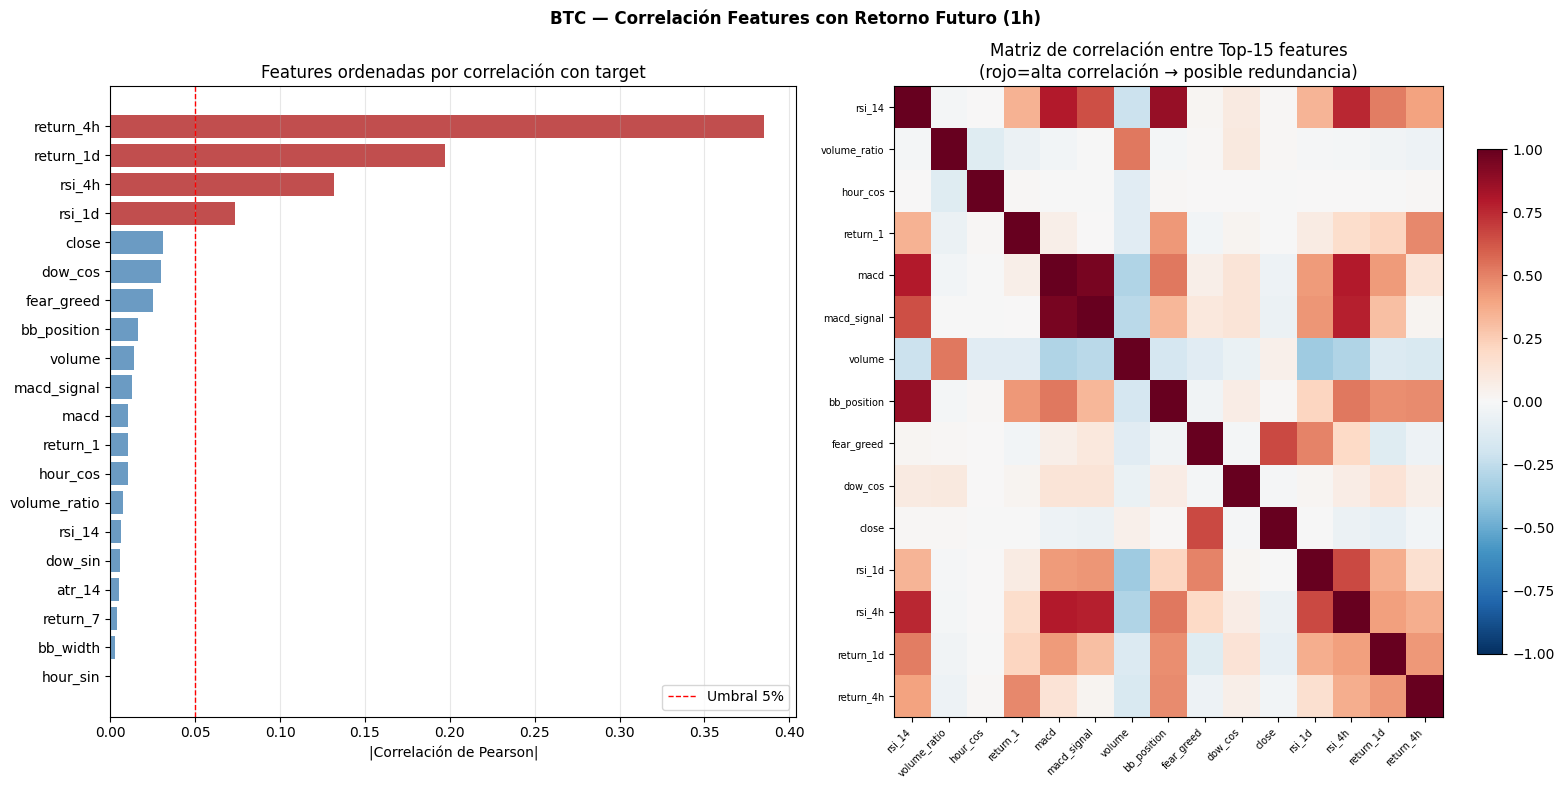


  BTC — Features con correlación > 5% (más predictivas):
    return_4h                : 0.3849
    return_1d                : 0.1970
    rsi_4h                   : 0.1317
    rsi_1d                   : 0.0733

  BTC — Features con correlación < 1% (candidatas a eliminar):
    hour_sin                 : 0.0006
    bb_width                 : 0.0028
    return_7                 : 0.0039
    atr_14                   : 0.0051
    dow_sin                  : 0.0057
    rsi_14                   : 0.0062
    volume_ratio             : 0.0074



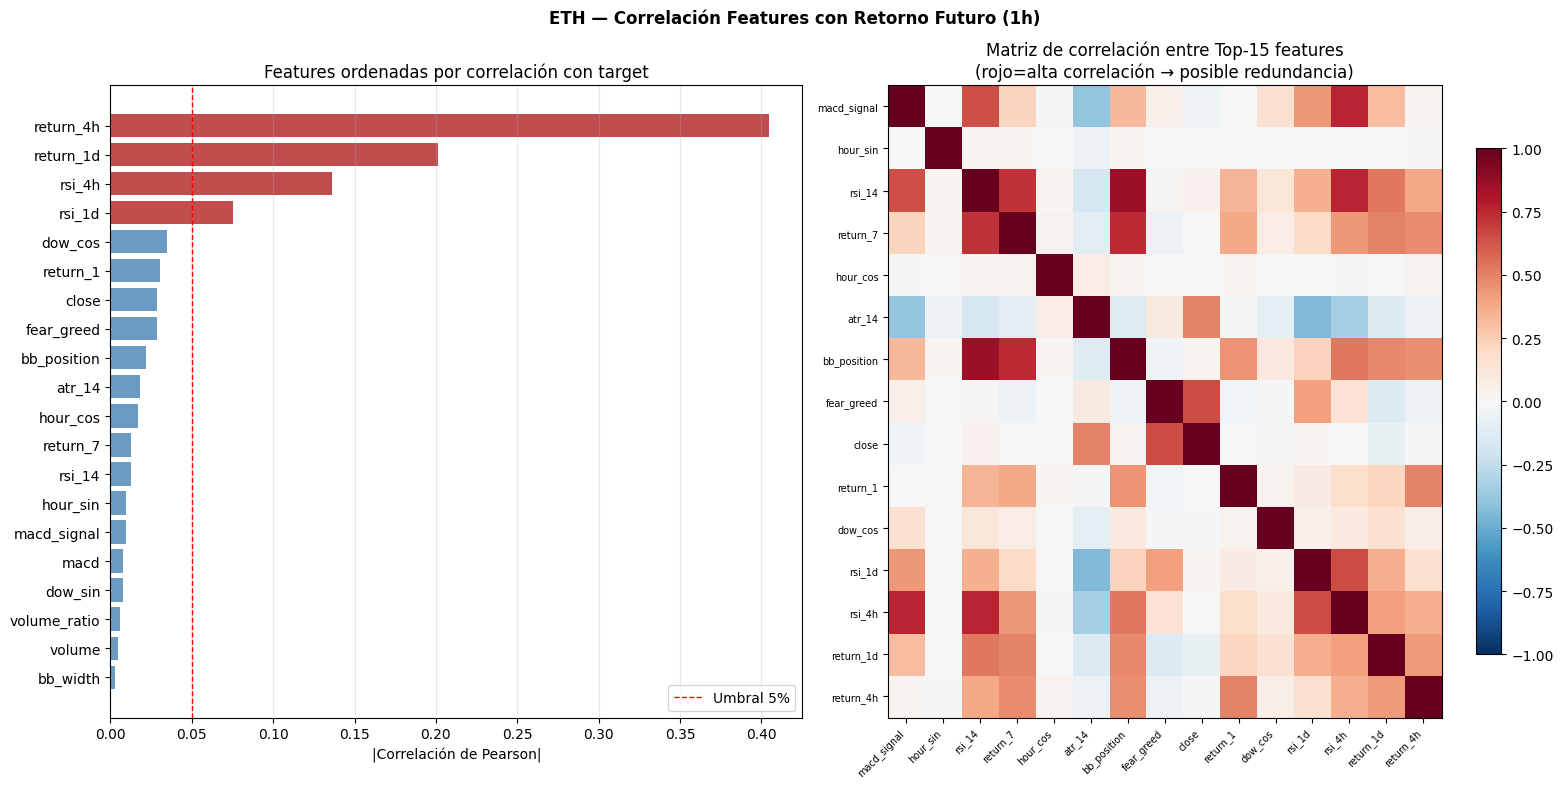


  ETH — Features con correlación > 5% (más predictivas):
    return_4h                : 0.4049
    return_1d                : 0.2011
    rsi_4h                   : 0.1362
    rsi_1d                   : 0.0753

  ETH — Features con correlación < 1% (candidatas a eliminar):
    bb_width                 : 0.0028
    volume                   : 0.0048
    volume_ratio             : 0.0058
    dow_sin                  : 0.0077
    macd                     : 0.0079
    macd_signal              : 0.0096
    hour_sin                 : 0.0099



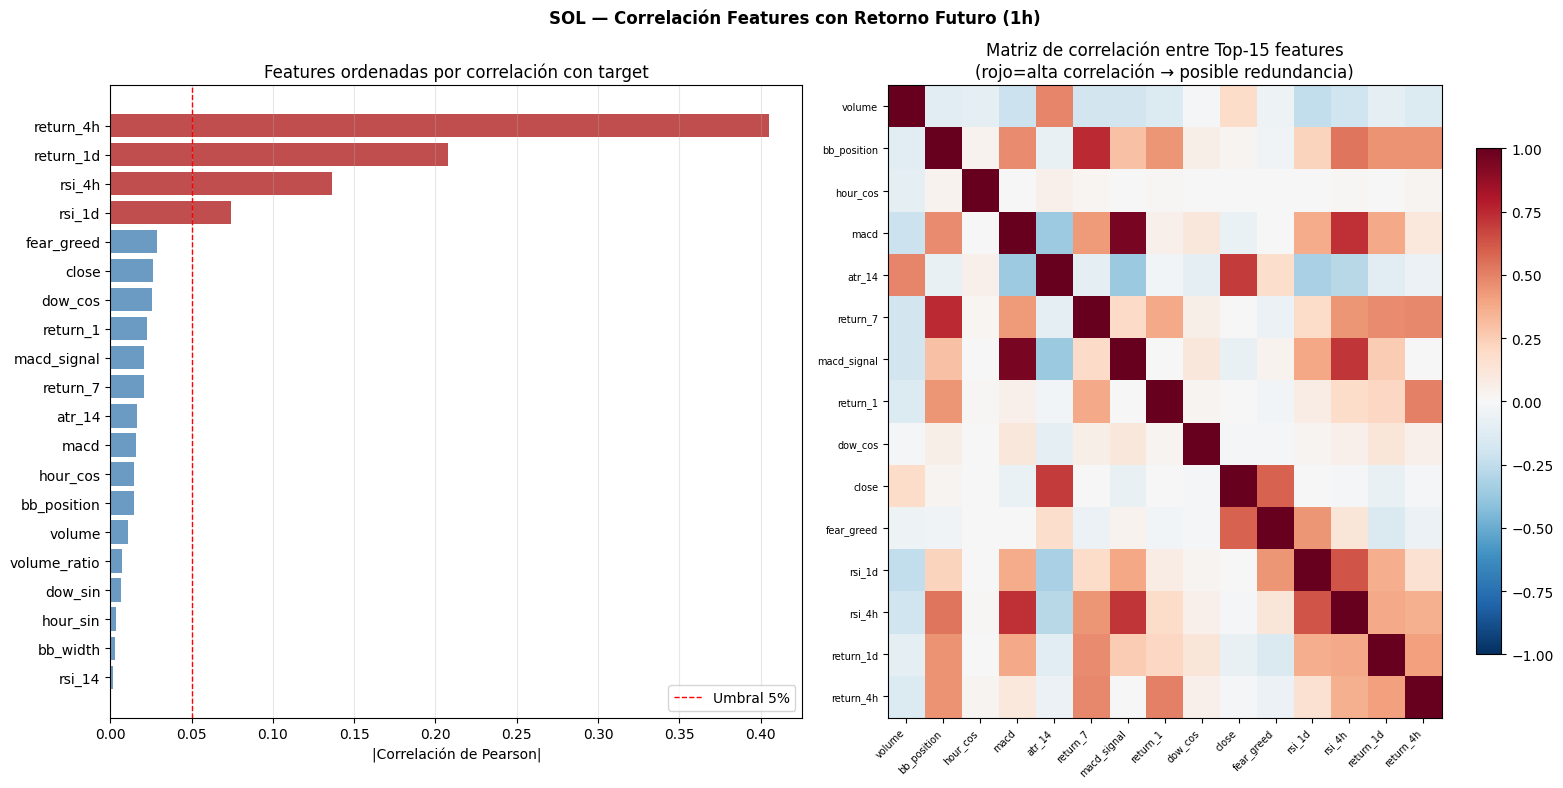


  SOL — Features con correlación > 5% (más predictivas):
    return_4h                : 0.4055
    return_1d                : 0.2075
    rsi_4h                   : 0.1363
    rsi_1d                   : 0.0739

  SOL — Features con correlación < 1% (candidatas a eliminar):
    rsi_14                   : 0.0017
    bb_width                 : 0.0029
    hour_sin                 : 0.0035
    dow_sin                  : 0.0066
    volume_ratio             : 0.0074



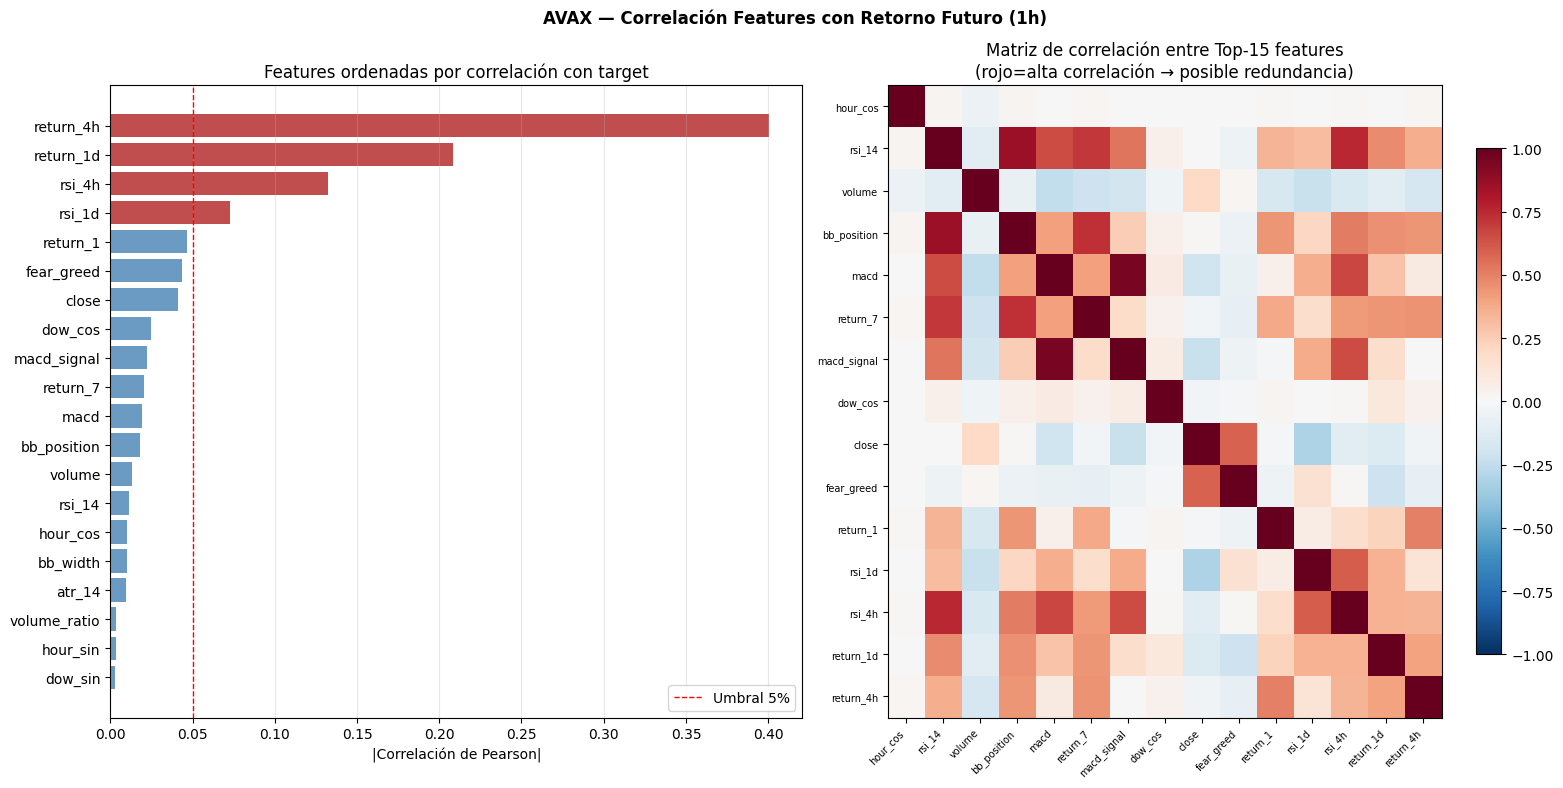


  AVAX — Features con correlación > 5% (más predictivas):
    return_4h                : 0.4007
    return_1d                : 0.2082
    rsi_4h                   : 0.1323
    rsi_1d                   : 0.0726

  AVAX — Features con correlación < 1% (candidatas a eliminar):
    dow_sin                  : 0.0026
    hour_sin                 : 0.0033
    volume_ratio             : 0.0035
    atr_14                   : 0.0096



In [9]:
# ─── 4. CORRELACIÓN FEATURES → TARGET (ahora sí existen los archivos) ───
print("\nAnalizando correlaciones feature→target (requiere datasets procesados)...")
for coin in BASE_CONFIG["coins"]:
    plot_feature_correlation(coin, BASE_CONFIG)
    print()

# 🗃️ Dataset y Preprocesamiento

In [10]:
class CryptoDataset(Dataset):
    def __init__(self, X: np.ndarray, yr: np.ndarray, noise_std: float = 0.0):
        self.X         = torch.tensor(X,  dtype=torch.float32)
        self.yr        = torch.tensor(yr, dtype=torch.float32)
        self.noise_std = noise_std
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        x = self.X[idx]
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return x, self.yr[idx]


def load_and_preprocess(coin, cfg):
    path = f"{cfg['data_dir']}/{coin}_{cfg['granularity']}.csv"
    df   = (pd.read_csv(path, parse_dates=["timestamp"])
              .sort_values("timestamp").reset_index(drop=True))

    feat_cols = [c for c in cfg["feature_cols"] if c in df.columns]
    reg_cols  = [f"target_ret_{h}" for h in cfg["horizons"]]
    df = df[feat_cols + reg_cols].dropna()

    n       = len(df)
    n_train = int(n * cfg["train_ratio"])
    n_val   = int(n * cfg["val_ratio"])

    train_df = df.iloc[:n_train]
    val_df   = df.iloc[n_train : n_train + n_val]
    test_df  = df.iloc[n_train + n_val:]

    feat_scaler = RobustScaler().fit(train_df[feat_cols].values)
    reg_scaler  = RobustScaler().fit(train_df[reg_cols].values)

    def scale_and_window(split_df):
        X  = feat_scaler.transform(split_df[feat_cols].values).astype(np.float32)
        yr = reg_scaler.transform(split_df[reg_cols].values).astype(np.float32)
        seq = cfg["seq_len"]
        Xs, yrs = [], []
        for i in range(seq, len(X)):
            Xs.append(X[i - seq : i])
            yrs.append(yr[i])
        return np.array(Xs, dtype=np.float32), np.array(yrs, dtype=np.float32)

    X_tr, yr_tr = scale_and_window(train_df)
    X_va, yr_va = scale_and_window(val_df)
    X_te, yr_te = scale_and_window(test_df)
    close_test  = test_df["close"].values[cfg["seq_len"]:]

    print(f"  {coin} → train: {X_tr.shape}, val: {X_va.shape}, "
          f"test: {X_te.shape} | features: {len(feat_cols)}")

    return (
        {"train": CryptoDataset(X_tr, yr_tr),
         "val":   CryptoDataset(X_va, yr_va),
         "test":  CryptoDataset(X_te, yr_te)},
        feat_scaler, reg_scaler, close_test, feat_cols,
    )


def make_loaders(datasets: dict, cfg: dict) -> dict:
    loaders = {}
    for split, ds in datasets.items():
        is_train = (split == "train")
        noise    = 0.01 if is_train else 0.0
        ds_noise = CryptoDataset(ds.X.numpy(), ds.yr.numpy(), noise_std=noise)
        loaders[split] = DataLoader(
            ds_noise,
            batch_size  = cfg["batch_size"],
            shuffle     = is_train,
            num_workers = 2,
            pin_memory  = (DEVICE.type == "cuda"),
            persistent_workers = True,
        )
    return loaders

print("✅ Dataset definido.")

✅ Dataset definido.


# 🧠 Modelo LSTM

In [11]:
class CryptoLSTM(nn.Module):
    """
    LSTM apilado con atención temporal aprendida.

    Diagrama del forward pass:
      x: (B, T, F)  — batch, seq_len, n_features
      → input_proj → (B, T, H)           Proyección lineal al espacio oculto
      → LSTM        → (B, T, H)           Todos los estados ocultos
      → attn_pool   → (B, H)             Suma ponderada (atención blanda)
      → norm + drop → (B, H)
      → mlp         → (B, head_hidden//2)
      → head        → (B, n_horizons)    Predicciones multi-horizonte
    """

    def __init__(self, n_features: int, n_horizons: int, cfg: dict):
        super().__init__()
        H = cfg["lstm_hidden"]
        head_h = cfg["head_hidden"]

        # ── Proyección de entrada ────────────────────────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, H),
            nn.LayerNorm(H),
        )

        # ── LSTM apilado ─────────────────────────────────────────────
        lstm_drop = cfg["lstm_dropout"] if cfg["lstm_layers"] > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size  = H,
            hidden_size = H,
            num_layers  = cfg["lstm_layers"],
            dropout     = lstm_drop,
            batch_first = True,
        )

        # ── Atención temporal (soft-pooling) ─────────────────────────
        # Aprende qué pasos temporales son más relevantes para predecir
        self.attn = nn.Linear(H, 1)

        # ── Normalización y regularización ───────────────────────────
        self.norm = nn.LayerNorm(H)
        self.drop = nn.Dropout(cfg["head_dropout"])

        # ── Cabeza de predicción MLP ──────────────────────────────────
        self.mlp = nn.Sequential(
            nn.Linear(H, head_h),
            nn.LayerNorm(head_h),
            nn.GELU(),
            nn.Dropout(cfg["head_dropout"]),
            nn.Linear(head_h, head_h // 2),
            nn.GELU(),
        )
        self.head = nn.Linear(head_h // 2, n_horizons)

        self._init_weights()

    def _init_weights(self):
        # Inicialización ortogonal para LSTM (evita vanishing/exploding gradients)
        for name, p in self.lstm.named_parameters():
            if "weight_ih" in name:   nn.init.xavier_uniform_(p.data)
            elif "weight_hh" in name: nn.init.orthogonal_(p.data)
            elif "bias" in name:
                p.data.zero_()
                n = p.size(0)
                # Bias de forget gate a 1.0 → mejor memoria a largo plazo
                p.data[n//4 : n//2].fill_(1.0)
        for m in self.modules():
            if isinstance(m, nn.Linear) and m is not self.head:
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, F)
        x = self.input_proj(x)                         # (B, T, H)
        lstm_out, _ = self.lstm(x)                     # (B, T, H)

        attn_w = torch.softmax(self.attn(lstm_out), dim=1)  # (B, T, 1)
        context = (attn_w * lstm_out).sum(dim=1)             # (B, H)

        context = self.drop(self.norm(context))        # (B, H)
        return self.head(self.mlp(context))            # (B, n_horizons)


class HorizonWeightedMSE(nn.Module):
    """Penaliza más los errores en horizontes cercanos (más importantes)."""
    def __init__(self, cfg):
        super().__init__()
        hw = torch.tensor(cfg["horizon_weights"], dtype=torch.float32)
        self.register_buffer("hw", hw / hw.sum())

    def forward(self, pred, true):
        return (nn.functional.mse_loss(pred, true, reduction="none") * self.hw).mean()


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ Modelo LSTM puro definido.")
print()
print("Comparativa de parámetros (estimación para BTC, 33 features, seq=72):")
cfg_btc = BEST_CONFIGS["BTC"]
lstm_only = CryptoLSTM(33, 4, cfg_btc)
print(f"  CryptoLSTM (puro):    {count_params(lstm_only):>8,} parámetros")

✅ Modelo LSTM puro definido.

Comparativa de parámetros (estimación para BTC, 33 features, seq=72):
  CryptoLSTM (puro):    1,081,445 parámetros


# 🏋️ Entrenamiento

In [12]:
def train_model(model, loaders, cfg, coin):
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
    )
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
    criterion = HorizonWeightedMSE(cfg).to(DEVICE)

    warmup_epochs = 5
    for g in optimizer.param_groups:
        g["lr"] = cfg["learning_rate"] / 10

    best_val, patience_c = float("inf"), 0
    ckpt    = f"{WORK_DIR}/best_{coin}.pt"
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, cfg["epochs"] + 1):
        if epoch == warmup_epochs + 1:
            for g in optimizer.param_groups:
                g["lr"] = cfg["learning_rate"]

        model.train()
        t_loss = 0.0
        for X, yr in loaders["train"]:
            X, yr = X.to(DEVICE), yr.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X), yr)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()
        t_loss /= len(loaders["train"])

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for X, yr in loaders["val"]:
                X, yr = X.to(DEVICE), yr.to(DEVICE)
                v_loss += criterion(model(X), yr).item()
        v_loss /= len(loaders["val"])

        if epoch > warmup_epochs:
            scheduler.step(epoch - warmup_epochs)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{cfg['epochs']} | "
                  f"Train {t_loss:.5f} | Val {v_loss:.5f}")

        if v_loss < best_val:
            best_val = v_loss; patience_c = 0
            torch.save(model.state_dict(), ckpt)
        else:
            patience_c += 1
            if patience_c >= cfg["patience"]:
                print(f"  ⏹ Early stopping epoch {epoch} (best val: {best_val:.5f})")
                break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    return history

print("✅ Entrenamiento definido.")

✅ Entrenamiento definido.


# 📊 Evaluación

In [13]:
def evaluate_model(model, loader, close_test, reg_scaler, horizons, coin):
    model.eval()
    rp_all, rt_all = [], []
    with torch.no_grad():
        for X, yr in loader:
            rp_all.append(model(X.to(DEVICE)).cpu().numpy())
            rt_all.append(yr.numpy())

    reg_pred = reg_scaler.inverse_transform(np.concatenate(rp_all))
    reg_true = reg_scaler.inverse_transform(np.concatenate(rt_all))

    def to_price(arr, idx):
        n = min(len(close_test), len(arr))
        return close_test[:n] * (1 + arr[:n, idx])

    results = []
    print(f"\n{'─'*65}")
    print(f"  {coin} — Resultados Test")
    print(f"{'─'*65}")
    print(f"  {'H':>4} | {'MAE USD':>10} | {'RMSE USD':>10} | {'MAPE%':>7} | {'DirAcc':>7}")
    print(f"  {'─'*4}-+-{'─'*10}-+-{'─'*10}-+-{'─'*7}-+-{'─'*7}")

    for i, h in enumerate(horizons):
        pp   = to_price(reg_pred, i)
        pt   = to_price(reg_true, i)
        n    = len(pp)
        mae  = mean_absolute_error(pt, pp)
        rmse = math.sqrt(mean_squared_error(pt, pp))
        mape = float(np.mean(np.abs((pt-pp)/(np.abs(pt)+1e-9))))*100
        dacc = float(np.mean(np.sign(reg_pred[:n,i]) == np.sign(reg_true[:n,i])))
        print(f"  {h:>2}h  | {mae:>10.2f} | {rmse:>10.2f} | {mape:>6.2f}% | {dacc:>7.3f}")
        results.append({"coin":coin,"horizon_h":h,"MAE":mae,"RMSE":rmse,"MAPE":mape,"DirAcc":dacc})

    return pd.DataFrame(results), reg_pred, reg_true


def moving_average_baseline(df_test, horizons, window=4):
    close, results = df_test["close"].values, []
    for h in horizons:
        p = [close[i-window:i].mean() for i in range(window, len(close)-h)]
        t = [close[i+h]               for i in range(window, len(close)-h)]
        p, t = np.array(p), np.array(t)
        results.append({"model":"Baseline","horizon_h":h,
                        "MAE": mean_absolute_error(t,p),
                        "RMSE":math.sqrt(mean_squared_error(t,p)),
                        "MAPE":float(np.mean(np.abs((t-p)/(np.abs(t)+1e-9))))*100})
    return pd.DataFrame(results)


def plot_attention_weights(model, loader, coin, n_samples=3):
    """
    Visualiza los pesos de atención del LSTM para entender qué pasos
    temporales usa el modelo para sus predicciones.
    """
    model.eval()
    fig, axes = plt.subplots(1, n_samples, figsize=(14, 3))
    fig.suptitle(f"{coin} — Pesos de Atención Temporal (qué horas pasadas importan más)",
                 fontsize=11, fontweight="bold")

    sample_idx = 0
    for X, _ in loader:
        if sample_idx >= n_samples: break
        x = X[0:1].to(DEVICE)
        with torch.no_grad():
            proj_x = model.input_proj(x)
            lstm_out, _ = model.lstm(proj_x)
            attn_w = torch.softmax(model.attn(lstm_out), dim=1).squeeze().cpu().numpy()

        ax = axes[sample_idx] if n_samples > 1 else axes
        ax.bar(range(len(attn_w)), attn_w, color="steelblue", alpha=0.7, width=1.0)
        ax.set_xlabel("Paso temporal (0=más antiguo, T=más reciente)")
        ax.set_ylabel("Peso de atención")
        ax.set_title(f"Muestra {sample_idx+1}")
        ax.grid(alpha=0.3)
        sample_idx += 1

    plt.tight_layout()
    plt.savefig(f"plots/{coin}_attention.png", dpi=120, bbox_inches="tight")
    plt.show()

def compute_diracc_full(reg_pred: np.ndarray, reg_true: np.ndarray) -> dict:
    """
    Calcula DirAcc SIN ningún filtro de umbral ni cooldown.
    Este es el número honesto: qué porcentaje de velas predice
    la dirección correcta sobre TODO el test set.
 
    Un modelo sin habilidad real debería dar ~50%.
    Superar 54% de forma consistente en walk-forward es genuinamente bueno.
    """
    results = {}
    n_h = reg_pred.shape[1]
    for i in range(n_h):
        pred_dir = np.sign(reg_pred[:, i])
        true_dir = np.sign(reg_true[:, i])
        dacc     = float(np.mean(pred_dir == true_dir))
        results[f"h{i+1}"] = dacc
        print(f"  DirAcc H{i+1} (sin filtro): {dacc*100:.2f}%  "
              f"{'✅ por encima del azar' if dacc > 0.52 else '⚠ cerca del azar'}")
    return results
 
 
def compute_profit_factor(trades: np.ndarray) -> float:
    """
    Profit factor = suma de ganancias / suma de pérdidas (en valor absoluto).
    > 1.0 → el sistema gana más de lo que pierde en total.
    < 1.5 → frágil, puede ser azar estadístico.
    > 2.0 → robusto si viene de muchos trades.
    """
    wins  = trades[trades > 0].sum()
    losses = np.abs(trades[trades < 0].sum())
    return float(wins / (losses + 1e-9))
 
 
def print_honest_metrics(coin: str, dacc_dict: dict, bt_result: dict | None):
    """Imprime un resumen honesto de métricas primarias y secundarias."""
    print(f"\n{'='*60}")
    print(f"  MÉTRICAS HONESTAS — {coin}")
    print(f"{'='*60}")
    print(f"\n  [PRIMARIA] DirAcc sin filtro (habilidad real del modelo):")
    for h, val in dacc_dict.items():
        bar = "█" * int(val * 50)
        print(f"    {h}: {val*100:.2f}%  {bar}")
 
    if bt_result is not None:
        trades = bt_result["retornos"]
        pf = compute_profit_factor(trades)
        n  = len(trades)
        print(f"\n  [SECUNDARIA] Backtesting (con umbral calibrado en TRAIN):")
        print(f"    Trades:         {n}")
        print(f"    Win rate:       {bt_result['win_rate']*100:.1f}%")
        print(f"    Profit factor:  {pf:.2f}  "
              f"{'✅' if pf > 1.5 else '⚠ insuficiente'}")
        print(f"    Retorno total:  {bt_result['ret_total']*100:.2f}%")
        print(f"    Sharpe:         {bt_result['sharpe']:.2f}")
        if n < 30:
            print(f"\n  ⚠ ADVERTENCIA: solo {n} trades. "
                  f"Con tan pocos trades el win rate no es estadísticamente significativo.")
            
print("✅ Evaluación definida.")

✅ Evaluación definida.


# 📈 Visualizaciones

In [14]:
def plot_history(history, coin):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history["train_loss"], label="Train", linewidth=1.5)
    ax.plot(history["val_loss"],   label="Val",   linewidth=1.5)
    ax.set_title(f"{coin} — Curva de Pérdida (LSTM Puro)")
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlabel("Época"); ax.set_ylabel("HorizonWeightedMSE")
    plt.tight_layout()
    plt.savefig(f"plots/{coin}_loss.png", dpi=120, bbox_inches="tight")
    plt.show()

def plot_preds(reg_pred, reg_true, close_test, coin, horizons, n=200):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for idx, (ax, h) in enumerate(zip(axes.flatten(), horizons)):
        nn_ = min(n, len(close_test))
        ax.plot(close_test[:nn_]*(1+reg_true[:nn_,idx]), label="Real",     alpha=0.85, linewidth=1.2)
        ax.plot(close_test[:nn_]*(1+reg_pred[:nn_,idx]), label="Predicho", alpha=0.85, linewidth=1.2, linestyle="--")
        ax.set_title(f"{coin} — {h}h"); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(f"{coin} — Precio real vs predicho (LSTM Puro)", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plots/{coin}_pred.png", dpi=120, bbox_inches="tight")
    plt.show()

def plot_comparison(lstm_res, base_res, coin):
    lr = lstm_res[["horizon_h","MAE","RMSE","MAPE"]].copy()
    lr["model"] = "LSTM Puro"
    combined = pd.concat([lr, base_res[["model","horizon_h","MAE","RMSE","MAPE"]]])
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, m in zip(axes, ["MAE","RMSE","MAPE"]):
        for name, grp in combined.groupby("model"):
            ax.plot(grp["horizon_h"], grp[m], marker="o", label=name, linewidth=2)
        ax.set_title(f"{m} — {coin}"); ax.legend(); ax.grid(alpha=0.3)
        ax.set_xlabel("Horizonte (horas)")
    plt.tight_layout()
    plt.savefig(f"plots/{coin}_cmp.png", dpi=120, bbox_inches="tight")
    plt.show()

print("✅ Visualizaciones definidas.")

✅ Visualizaciones definidas.


In [15]:
def walk_forward_validation(coin: str, cfg: dict, n_folds: int = 5, comision: float = 0.001) -> pd.DataFrame:
    """
    Walk-forward validation: la forma honesta de evaluar modelos de series temporales.
 
    Esquema visual (5 folds sobre el 85% de datos disponibles):
    ┌────────────────────────────────────────────────────────┐
    │ fold 1: TRAIN────────┤ VAL─┤ TEST─┤                   │
    │ fold 2: TRAIN──────────────┤ VAL─┤ TEST─┤             │
    │ fold 3: TRAIN────────────────────┤ VAL─┤ TEST─┤       │
    │ fold 4: TRAIN──────────────────────────┤ VAL─┤ TEST─┤ │
    │ fold 5: TRAIN────────────────────────────────┤VAL┤TST┤ │
    └────────────────────────────────────────────────────────┘
 
    El test del fold i nunca se usa para calibrar el fold i+1.
    El umbral se calcula en el TRAIN de cada fold.
 
    Devuelve un DataFrame con DirAcc y métricas por fold.
    """
    print(f"\n{'='*60}")
    print(f"  WALK-FORWARD VALIDATION — {coin} ({n_folds} folds)")
    print(f"{'='*60}")
 
    path = f"{cfg['data_dir']}/{coin}_{cfg['granularity']}.csv"

    if not os.path.exists(path):
        print(f"  ⚠ {path} no encontrado")
        return pd.DataFrame()
 
    df       = pd.read_csv(path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    feat_cols = [c for c in cfg["feature_cols"] if c in df.columns]
    reg_cols  = [f"target_ret_{h}" for h in cfg["horizons"]]
    df        = df[feat_cols + reg_cols + ["close"]].dropna().reset_index(drop=True)
    n         = len(df)
 
    # Reservamos el 15% final como holdout ABSOLUTO — no se toca
    holdout_start = int(n * 0.85)
    df_wf         = df.iloc[:holdout_start].reset_index(drop=True)
    n_wf          = len(df_wf)
 
    fold_size  = n_wf // (n_folds + 1)
    val_size   = max(fold_size // 3, cfg["seq_len"] * 5)
    test_size  = max(fold_size // 3, cfg["seq_len"] * 5)
    min_train  = cfg["seq_len"] * 10
 
    fold_results = []
 
    for fold in range(n_folds):
        test_end   = n_wf - fold * fold_size
        test_start = max(test_end - test_size, min_train + val_size)
        val_start  = max(test_start - val_size, min_train)
        train_end  = val_start
 
        if train_end < min_train:
            print(f"  Fold {fold+1}: datos insuficientes, omitiendo")
            continue
 
        train_df = df_wf.iloc[:train_end].reset_index(drop=True)
        val_df   = df_wf.iloc[val_start:test_start].reset_index(drop=True)
        test_df  = df_wf.iloc[test_start:test_end].reset_index(drop=True)
 
        print(f"\n  Fold {fold+1}/{n_folds} | "
              f"train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")
 
        if len(val_df) < cfg["seq_len"] * 2 or len(test_df) < cfg["seq_len"] * 2:
            print(f"  Fold {fold+1}: segmentos demasiado pequeños, omitiendo")
            continue
 
        # Scaler ajustado SOLO en train
        feat_scaler = RobustScaler().fit(train_df[feat_cols].values)
        reg_scaler  = RobustScaler().fit(train_df[reg_cols].values)
 
        def make_windows(split_df):
            X_sc  = feat_scaler.transform(split_df[feat_cols].values).astype(np.float32)
            yr_sc = reg_scaler.transform(split_df[reg_cols].values).astype(np.float32)
            seq   = cfg["seq_len"]
            Xs, yrs = [], []
            for i in range(seq, len(X_sc)):
                Xs.append(X_sc[i-seq:i])
                yrs.append(yr_sc[i])
            if not Xs:
                return np.empty((0, cfg["seq_len"], len(feat_cols))), np.empty((0, len(reg_cols)))
            return np.array(Xs, dtype=np.float32), np.array(yrs, dtype=np.float32)
 
        X_tr, yr_tr = make_windows(train_df)
        X_va, yr_va = make_windows(val_df)
        X_te, yr_te = make_windows(test_df)
 
        if len(X_tr) == 0 or len(X_te) == 0:
            continue
 
        # Modelo nuevo para cada fold
        n_feat = X_tr.shape[2]
        model  = CryptoLSTM(n_feat, len(cfg["horizons"]), cfg).to(DEVICE)
 
        datasets = {
            "train": CryptoDataset(X_tr, yr_tr, noise_std=0.01),
            "val":   CryptoDataset(X_va, yr_va, noise_std=0.0),
            "test":  CryptoDataset(X_te, yr_te, noise_std=0.0),
        }
        loaders = {
            split: DataLoader(ds, batch_size=cfg["batch_size"],
                              shuffle=(split == "train"),
                              num_workers=2, pin_memory=(DEVICE.type == "cuda"))
            for split, ds in datasets.items()
        }
 
        # Entrenamiento rápido (menos épocas por fold)
        cfg_fold = {**cfg, "epochs": 60, "patience": 10}
        history  = train_model(model, loaders, cfg_fold, f"{coin}_fold{fold+1}")
 
        # Evaluación en test del fold
        model.eval()
        rp_all, rt_all = [], []
        with torch.no_grad():
            for X, yr in loaders["test"]:
                rp_all.append(model(X.to(DEVICE)).cpu().numpy())
                rt_all.append(yr.numpy())
 
        reg_pred = reg_scaler.inverse_transform(np.concatenate(rp_all))
        reg_true = reg_scaler.inverse_transform(np.concatenate(rt_all))
 
        # DirAcc por horizonte (métrica primaria)
        row = {"fold": fold + 1, "n_test": len(reg_pred)}
        for i, h in enumerate(cfg["horizons"]):
            dacc = float(np.mean(np.sign(reg_pred[:, i]) == np.sign(reg_true[:, i])))
            row[f"DirAcc_H{h}"] = dacc
 
        # Umbral calibrado en TRAIN del fold
        train_prices = train_df["close"].values.ravel()
        tr_returns   = np.diff(train_prices) / (train_prices[:-1] + 1e-9)
        sigma_4h     = float(np.std(tr_returns)) * np.sqrt(4)
        umbral       = float(np.clip(sigma_4h * 0.8, 0.001, 0.006))
        row["umbral_train"] = umbral
 
        # Win rate filtrado (métrica secundaria)
        close_test_fold = test_df["close"].values[cfg["seq_len"]:]
        n_bt = min(len(close_test_fold) - 4, len(reg_pred) - 4)
        trades_fold = []
        cd = 0
        for i in range(n_bt - 4):
            if cd > 0:
                cd -= 1
                continue
            pb = (close_test_fold[min(i+4, n_bt-1)] - close_test_fold[i]) / close_test_fold[i]
            if reg_pred[i, 3] > umbral:
                trades_fold.append(pb - 2 * comision)
                cd = 2
            elif reg_pred[i, 3] < -umbral:
                trades_fold.append(-pb - 2 * comision)
                cd = 2
 
        if trades_fold:
            ta = np.array(trades_fold)
            row["win_rate"]  = float(np.mean(ta > 0))
            row["n_trades"]  = len(ta)
            row["ret_total"] = float(np.prod(1 + ta) - 1)
            row["profit_factor"] = compute_profit_factor(ta)
        else:
            row["win_rate"] = None
            row["n_trades"] = 0
            row["ret_total"] = 0.0
            row["profit_factor"] = None
 
        fold_results.append(row)
        print(f"  Fold {fold+1} → "
              + " | ".join(f"DirAcc_H{h}: {row[f'DirAcc_H{h}']*100:.1f}%"
                           for h in cfg["horizons"])
              + (f" | WinRate: {row['win_rate']*100:.1f}%" if row['win_rate'] else ""))
 
    if not fold_results:
        return pd.DataFrame()
 
    df_res = pd.DataFrame(fold_results)
 
    print(f"\n  {'─'*60}")
    print(f"  RESUMEN WALK-FORWARD — {coin}")
    print(f"  {'─'*60}")
    for h in cfg["horizons"]:
        col   = f"DirAcc_H{h}"
        mean  = df_res[col].mean()
        std   = df_res[col].std()
        print(f"  DirAcc H{h}: {mean*100:.2f}% ± {std*100:.2f}%  "
              f"{'✅ habilidad real' if mean > 0.52 else '⚠ cerca del azar'}")
 
    if "win_rate" in df_res.columns and df_res["win_rate"].notna().any():
        wr_mean = df_res["win_rate"].mean()
        pf_mean = df_res["profit_factor"].mean()
        print(f"  Win rate medio:    {wr_mean*100:.1f}%  (con umbral calibrado en train)")
        print(f"  Profit factor med: {pf_mean:.2f}")
 
    return df_res
 
 
def run_all_wf(coins: list, configs: dict, n_folds: int = 5) -> dict:
    """Ejecuta walk-forward para todas las monedas y consolida resultados."""
    all_wf = {}
    for coin in coins:
        cfg = configs.get(coin, BASE_CONFIG)
        try:
            df_res = walk_forward_validation(coin, cfg, n_folds=n_folds)
            all_wf[coin] = df_res
        except Exception:
            import traceback
            traceback.print_exc()
    return all_wf

# 🚀 Pipeline Principal

In [16]:
COMISION = 0.001  # 0.1% por operación (estándar Binance)

def calibrate_threshold_on_train(coin: str, cfg: dict) -> float:
    """
    CAMBIO PRINCIPAL: calcula el umbral adaptativo usando SOLO los datos
    de entrenamiento (no el test set completo como antes).
 
    Esto elimina el data leakage: en producción, cuando ves una señal,
    no conoces la volatilidad futura del período de test.
    """
    path = f"{cfg['data_dir']}/{coin}_{cfg['granularity']}.csv"
    df   = pd.read_csv(path, parse_dates=["timestamp"]).sort_values("timestamp")
    n    = len(df)
    n_tr = int(n * cfg["train_ratio"])
 
    train_prices = df["close"].values[:n_tr]
    returns      = np.diff(train_prices) / train_prices[:-1]
    sigma        = float(np.std(returns))
    sigma_4h     = sigma * np.sqrt(4)
    umbral       = float(np.clip(sigma_4h * 0.8, 0.001, 0.006))
 
    print(f"  {coin}: umbral calibrado en TRAIN = {umbral*100:.3f}%  "
          f"(σ_4h_train = {sigma_4h*100:.3f}%)")
    return umbral
 
 
def run_backtest_fixed(coin: str, result: dict, cfg: dict, cooldown_velas: int = 2) -> dict | None:
    """
    Backtest con umbral calibrado en TRAIN (sin data leakage).
    Todo lo demás igual que el original.
    """
    # Calibrar umbral SOLO en datos de entrenamiento
    umbral_ret = calibrate_threshold_on_train(coin, cfg)
 
    reg_pred   = result["reg_pred"]
    close_test = result["close_test"]
    h_idx      = 3  # horizonte 4h
 
    n       = min(len(close_test) - 4, len(reg_pred) - 4)
    precios = close_test[:n]
    señales = reg_pred[:n, h_idx]
 
    capital  = 1000.0
    trades   = []
    cooldown = 0
    n_long = n_short = 0
 
    for i in range(n - 4):
        if cooldown > 0:
            cooldown -= 1
            continue
 
        p_entrada = precios[i]
        p_salida  = precios[min(i + 4, n - 1)]
        ret_bruto = (p_salida - p_entrada) / p_entrada
 
        if señales[i] > umbral_ret:
            ret_neto  = ret_bruto - 2 * COMISION
            capital  *= (1 + ret_neto)
            trades.append(ret_neto)
            cooldown = cooldown_velas
            n_long += 1
        elif señales[i] < -umbral_ret:
            ret_neto  = -ret_bruto - 2 * COMISION
            capital  *= (1 + ret_neto)
            trades.append(ret_neto)
            cooldown = cooldown_velas
            n_short += 1
 
    ret_hold = (precios[-1] - precios[0]) / precios[0]
    if len(trades) == 0:
        print(f"  {coin}: sin trades con umbral {umbral_ret*100:.3f}%")
        return None
 
    trades_arr  = np.array(trades)
    win_rate    = float(np.mean(trades_arr > 0))
    ret_medio   = float(np.mean(trades_arr))
    ret_total   = float(capital / 1000.0 - 1)
    sharpe      = (ret_medio / (trades_arr.std() + 1e-9)) * np.sqrt(252 * 6)
    pf          = compute_profit_factor(trades_arr)
 
    print(f"\n  {coin} — Backtesting (umbral TRAIN {umbral_ret*100:.3f}%, cooldown {cooldown_velas}v)")
    print(f"  {'─'*60}")
    print(f"    Trades realizados:   {len(trades):4d}  (LONG: {n_long}, SHORT: {n_short})")
    print(f"    Win rate:            {win_rate*100:.1f}%")
    print(f"    Profit factor:       {pf:.2f}")
    print(f"    Retorno medio/trade: {ret_medio*100:.3f}% (neto)")
    print(f"    Retorno total:       {ret_total*100:.2f}% (neto)")
    print(f"    Sharpe (anual.):     {sharpe:.2f}")
    print(f"    Hold (buy & hold):   {ret_hold*100:.2f}%")
    if len(trades) < 30:
        print(f"    ⚠ Solo {len(trades)} trades — baja significancia estadística")
    print(f"    {'✅ Modelo supera hold' if ret_total > ret_hold else '⚠  Hold supera al modelo'}")
 
    return {
        "coin": coin, "n_trades": len(trades), "win_rate": win_rate,
        "ret_total": ret_total, "ret_hold": ret_hold, "sharpe": sharpe,
        "profit_factor": pf, "retornos": trades_arr,
    }

# 📉 Backtesting con Comisiones Reales


  BTC | seq=24 lstm_h=256 layers=2 lr=1.74e-03
  BTC → train: (38618, 24, 20), val: (8256, 24, 20), test: (8258, 24, 20) | features: 20
  Parámetros: 1,078,117 | Features: 20
  Epoch   1/150 | Train 0.48575 | Val 0.27996
  Epoch  10/150 | Train 0.40097 | Val 0.24913
  Epoch  20/150 | Train 0.27456 | Val 0.23891
  Epoch  30/150 | Train 0.33535 | Val 0.24372
  ⏹ Early stopping epoch 37 (best val: 0.23484)


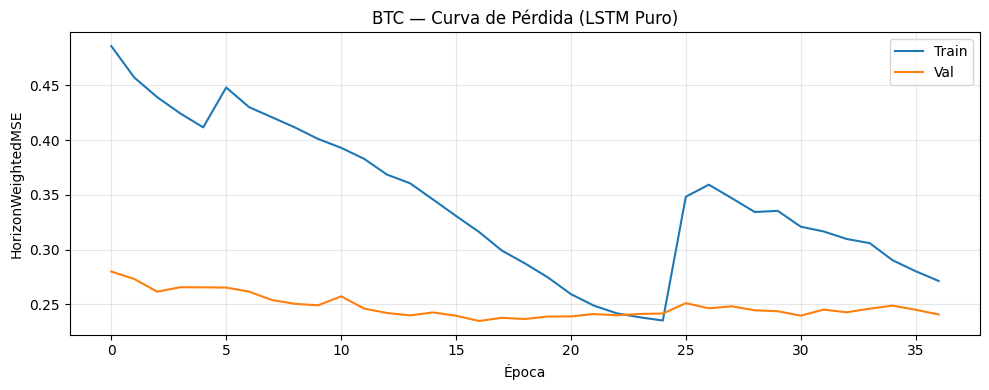

  💾 model_BTC.pt + scaler_BTC.pkl guardados

─────────────────────────────────────────────────────────────────
  BTC — Resultados Test
─────────────────────────────────────────────────────────────────
     H |    MAE USD |   RMSE USD |   MAPE% |  DirAcc
  ────-+-──────────-+-──────────-+-───────-+-───────
   1h  |     257.92 |     371.99 |   0.28% |   0.590
   2h  |     358.98 |     508.38 |   0.39% |   0.612
   3h  |     436.88 |     616.46 |   0.47% |   0.620
   4h  |     499.95 |     699.97 |   0.54% |   0.640


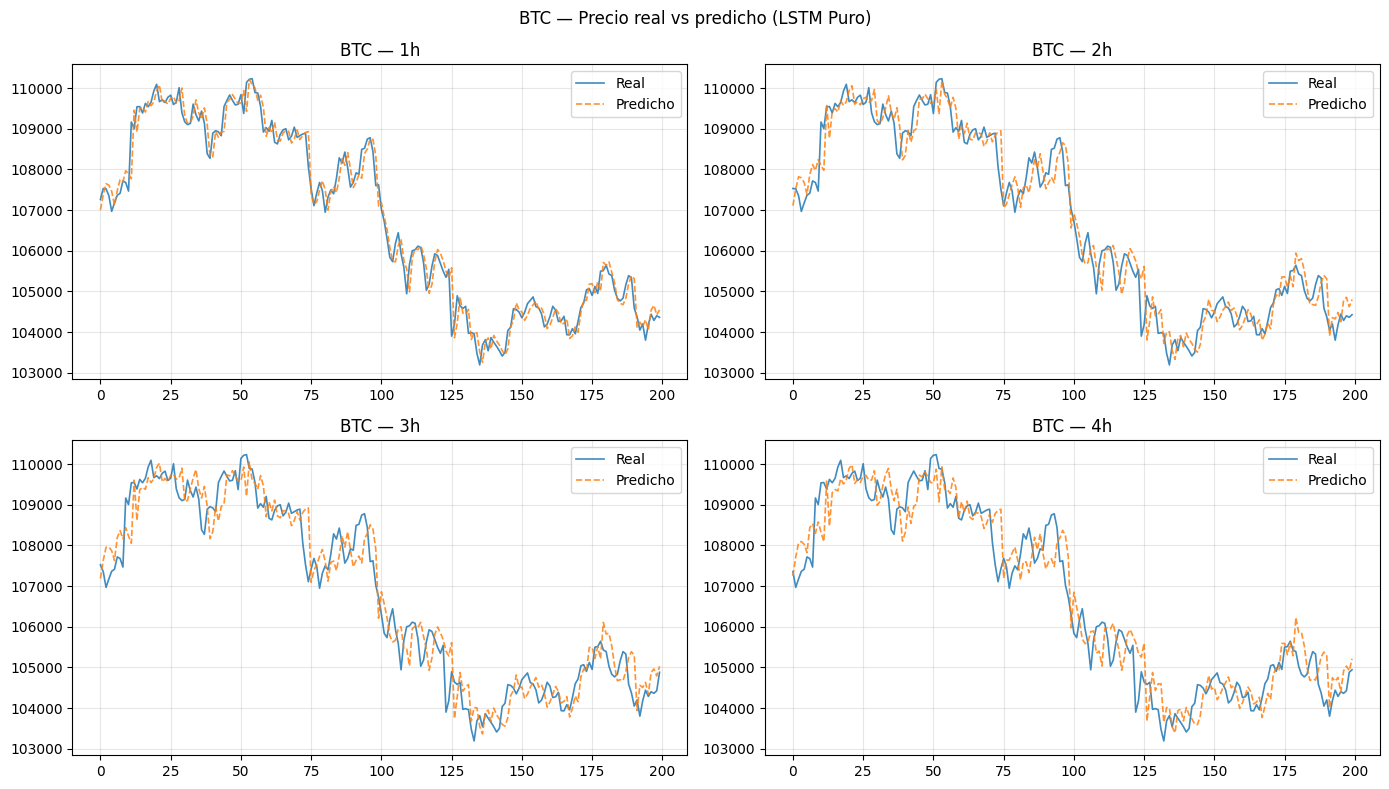

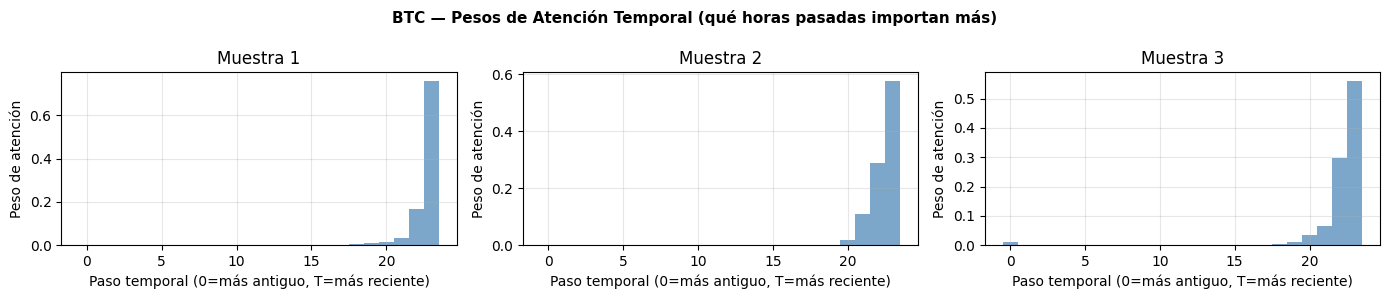

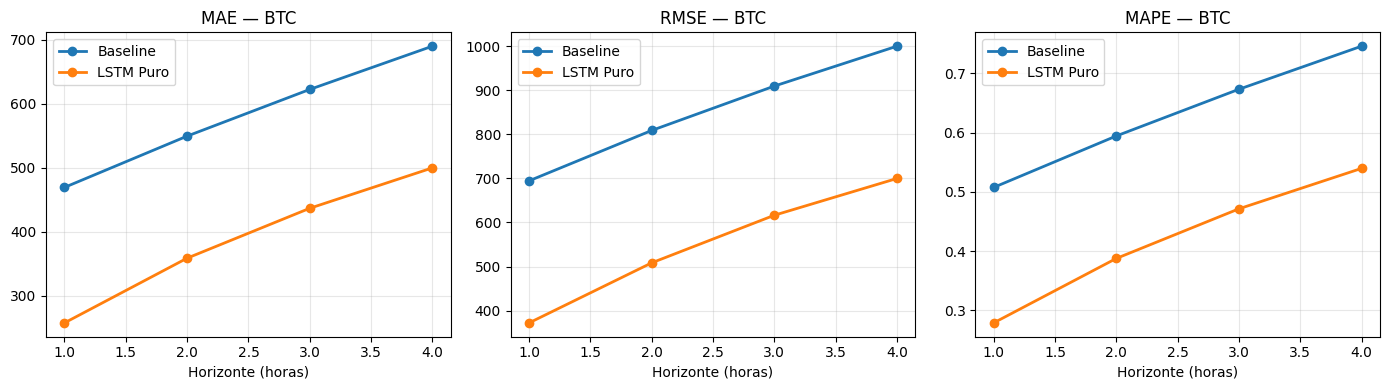


  ETH | seq=24 lstm_h=64 layers=3 lr=1.72e-03
  ETH → train: (38618, 24, 20), val: (8256, 24, 20), test: (8258, 24, 20) | features: 20
  Parámetros: 108,005 | Features: 20
  Epoch   1/150 | Train 0.45338 | Val 0.33174
  Epoch  10/150 | Train 0.36522 | Val 0.27254
  Epoch  20/150 | Train 0.27951 | Val 0.26983
  Epoch  30/150 | Train 0.29618 | Val 0.27426
  ⏹ Early stopping epoch 39 (best val: 0.26978)


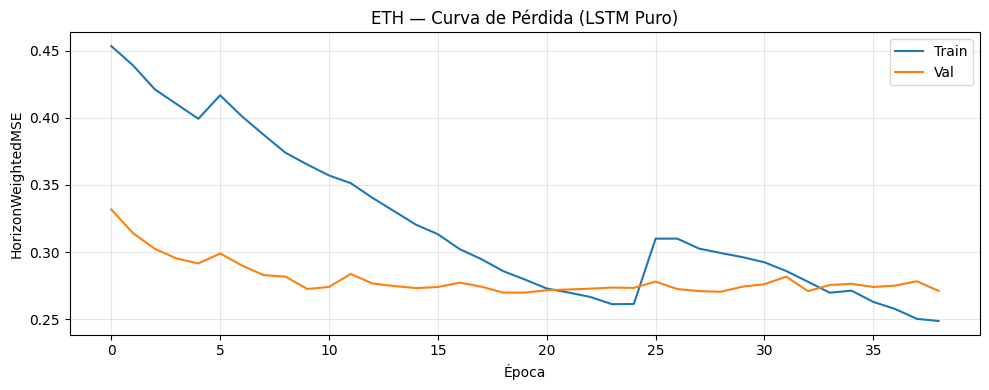

  💾 model_ETH.pt + scaler_ETH.pkl guardados

─────────────────────────────────────────────────────────────────
  ETH — Resultados Test
─────────────────────────────────────────────────────────────────
     H |    MAE USD |   RMSE USD |   MAPE% |  DirAcc
  ────-+-──────────-+-──────────-+-───────-+-───────
   1h  |      13.16 |      19.73 |   0.43% |   0.596
   2h  |      18.22 |      26.61 |   0.59% |   0.630
   3h  |      21.92 |      31.85 |   0.71% |   0.640
   4h  |      24.92 |      36.21 |   0.81% |   0.655


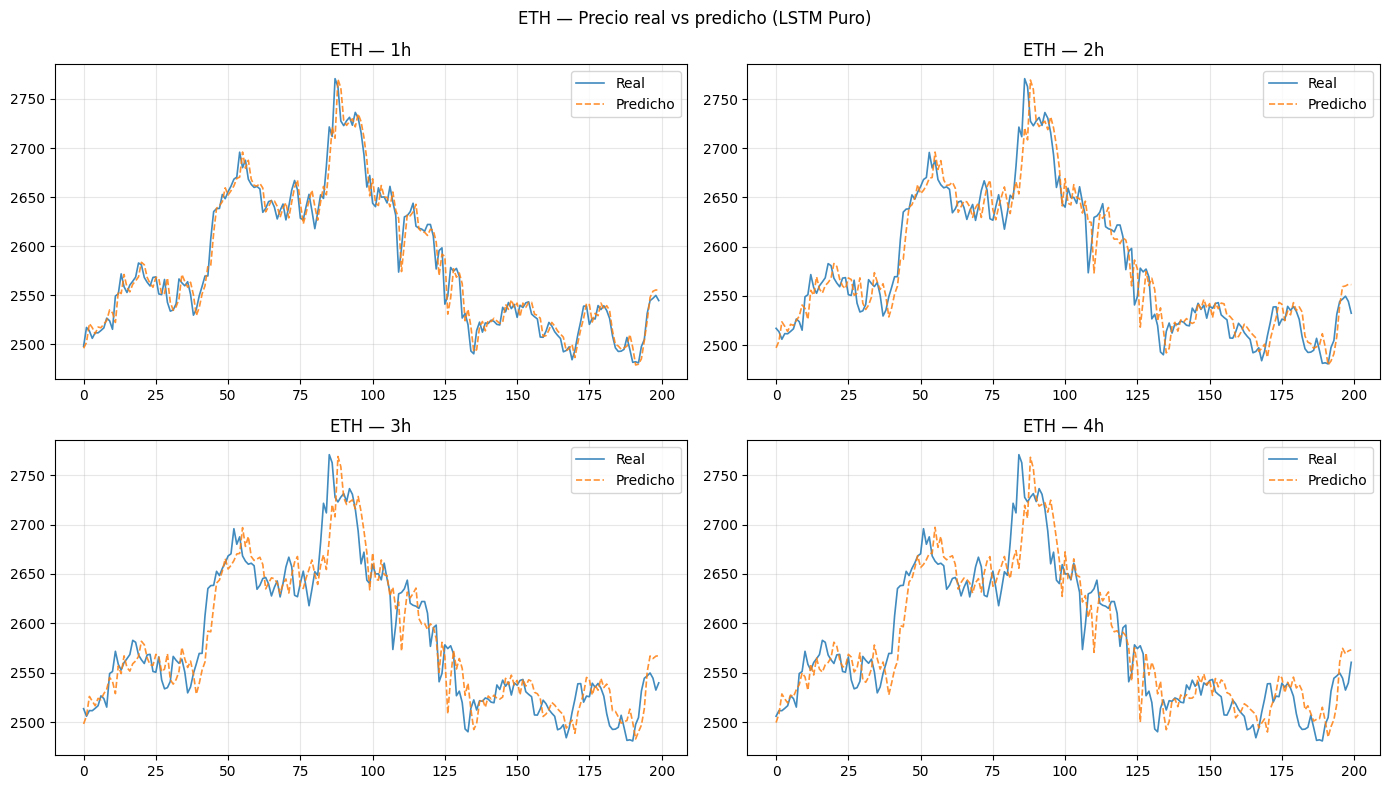

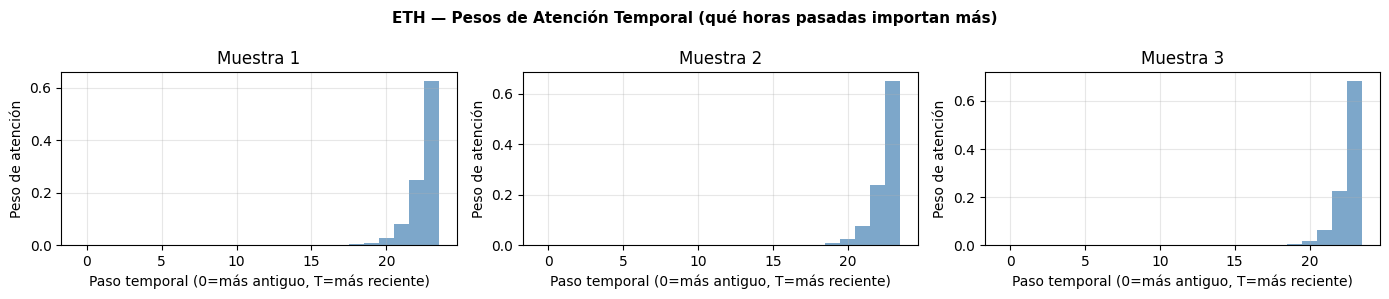

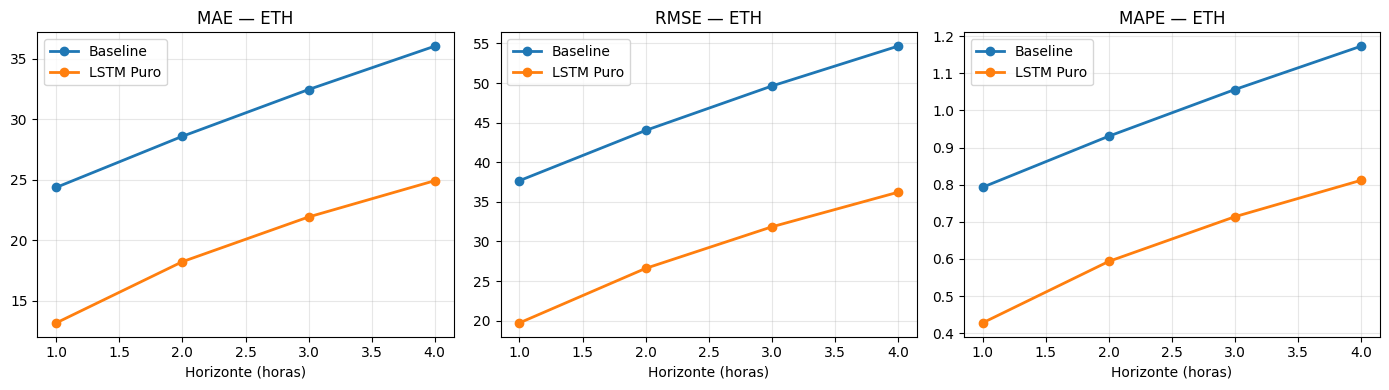


  SOL | seq=24 lstm_h=256 layers=2 lr=1.90e-04
  SOL → train: (34242, 24, 20), val: (7318, 24, 20), test: (7320, 24, 20) | features: 20
  Parámetros: 1,078,117 | Features: 20
  Epoch   1/150 | Train 0.36079 | Val 0.16151
  Epoch  10/150 | Train 0.29926 | Val 0.14057
  Epoch  20/150 | Train 0.23030 | Val 0.14558
  Epoch  30/150 | Train 0.23240 | Val 0.14595
  ⏹ Early stopping epoch 36 (best val: 0.13972)


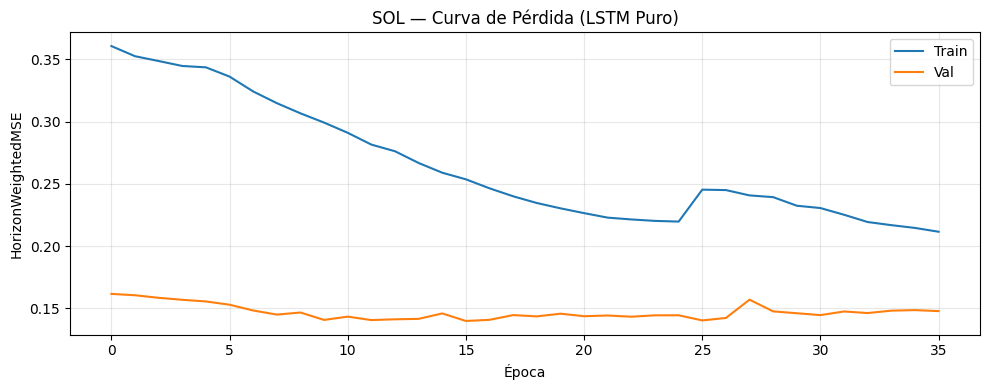

  💾 model_SOL.pt + scaler_SOL.pkl guardados

─────────────────────────────────────────────────────────────────
  SOL — Resultados Test
─────────────────────────────────────────────────────────────────
     H |    MAE USD |   RMSE USD |   MAPE% |  DirAcc
  ────-+-──────────-+-──────────-+-───────-+-───────
   1h  |       0.77 |       1.14 |   0.52% |   0.554
   2h  |       1.07 |       1.58 |   0.73% |   0.589
   3h  |       1.27 |       1.86 |   0.87% |   0.609
   4h  |       1.43 |       2.09 |   0.99% |   0.632


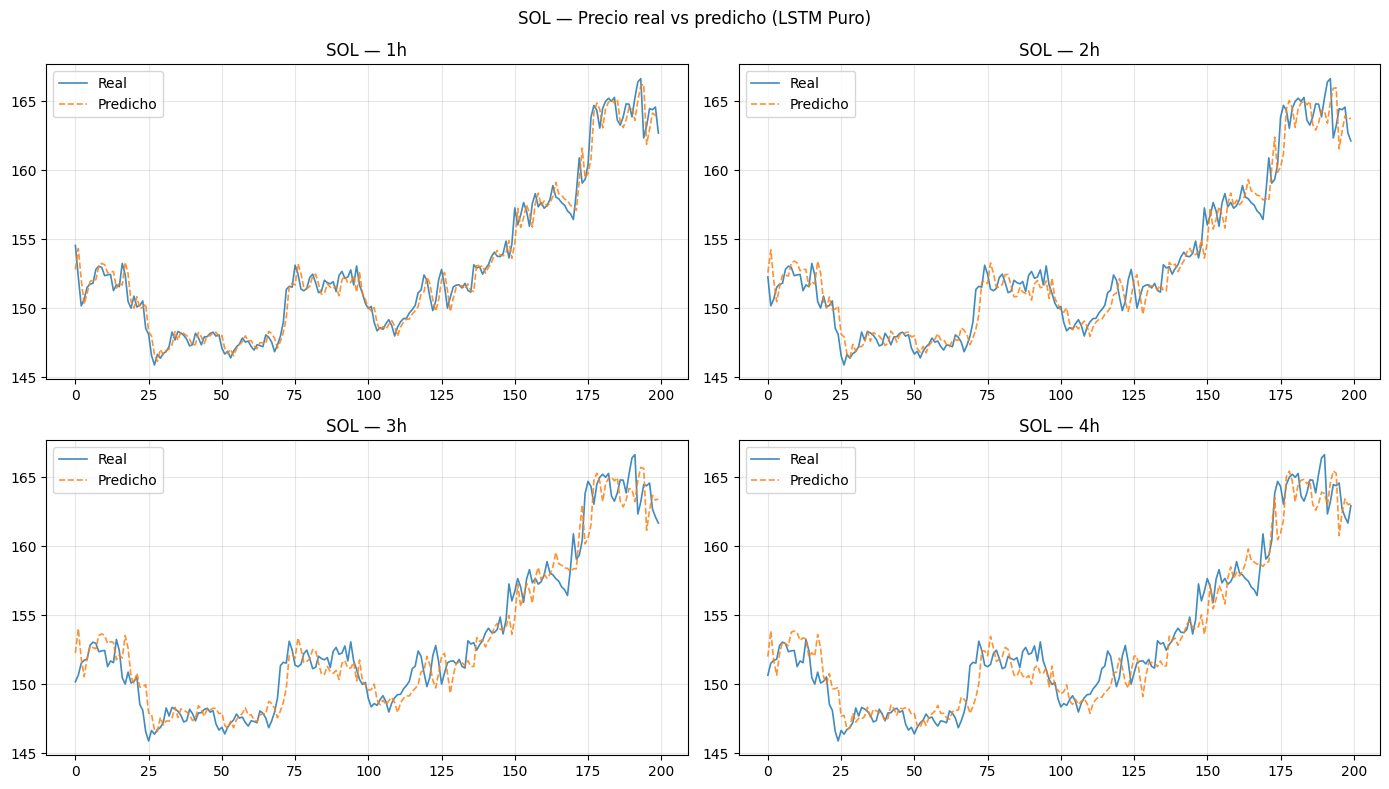

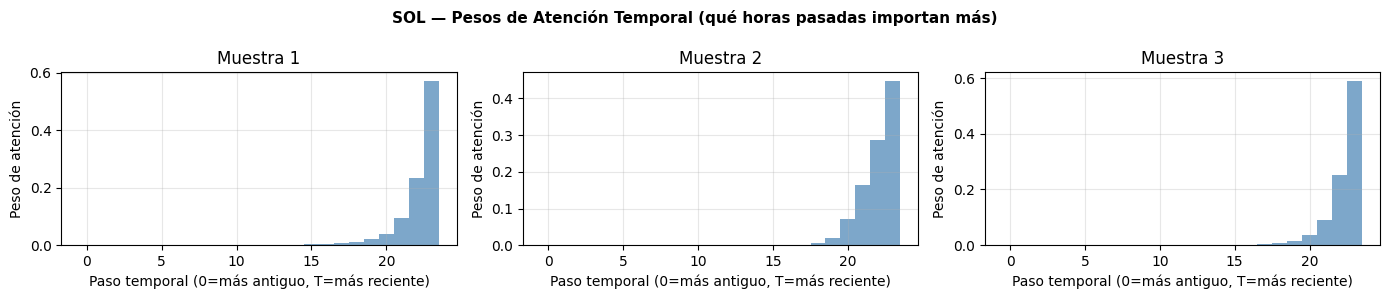

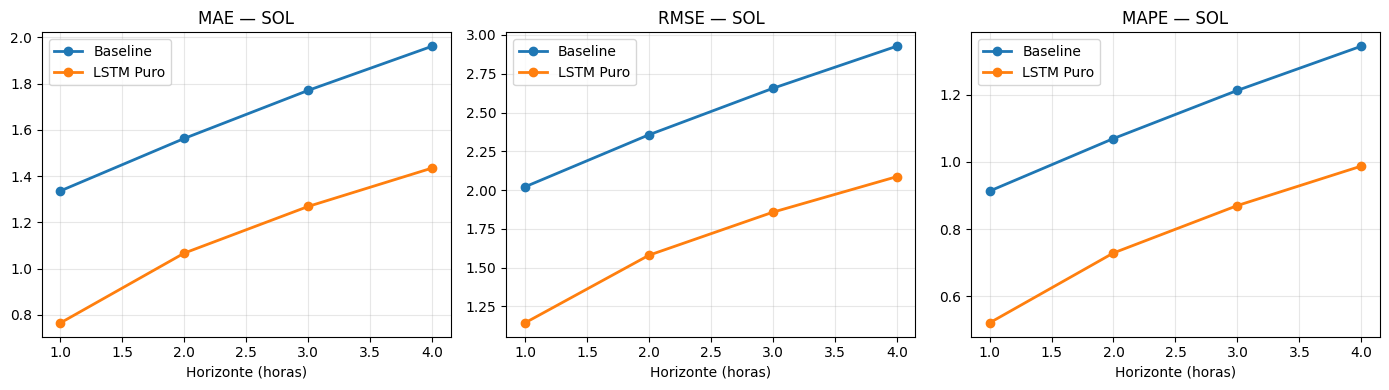


  AVAX | seq=48 lstm_h=128 layers=2 lr=2.86e-04
  AVAX → train: (27074, 48, 20), val: (5764, 48, 20), test: (5765, 48, 20) | features: 20
  Parámetros: 272,309 | Features: 20
  Epoch   1/150 | Train 0.35694 | Val 0.28878
  Epoch  10/150 | Train 0.31742 | Val 0.25918
  Epoch  20/150 | Train 0.26152 | Val 0.26127
  Epoch  30/150 | Train 0.26019 | Val 0.25984
  ⏹ Early stopping epoch 33 (best val: 0.25193)


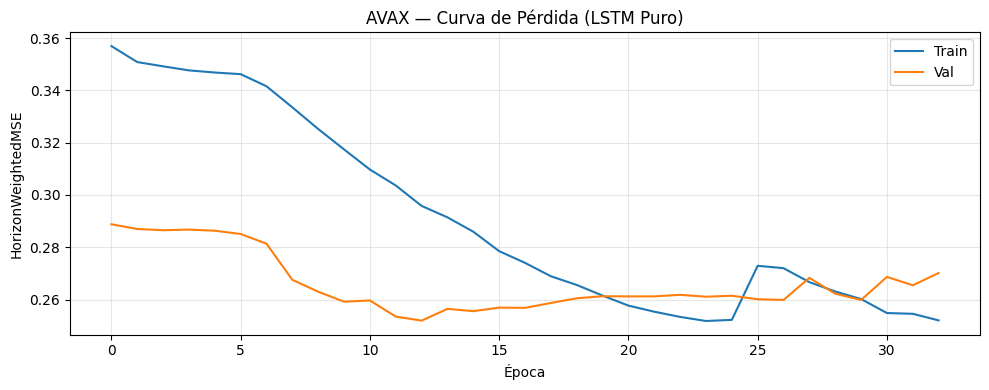

  💾 model_AVAX.pt + scaler_AVAX.pkl guardados

─────────────────────────────────────────────────────────────────
  AVAX — Resultados Test
─────────────────────────────────────────────────────────────────
     H |    MAE USD |   RMSE USD |   MAPE% |  DirAcc
  ────-+-──────────-+-──────────-+-───────-+-───────
   1h  |       0.09 |       0.15 |   0.55% |   0.507
   2h  |       0.12 |       0.21 |   0.78% |   0.537
   3h  |       0.15 |       0.26 |   0.94% |   0.560
   4h  |       0.17 |       0.30 |   1.08% |   0.569


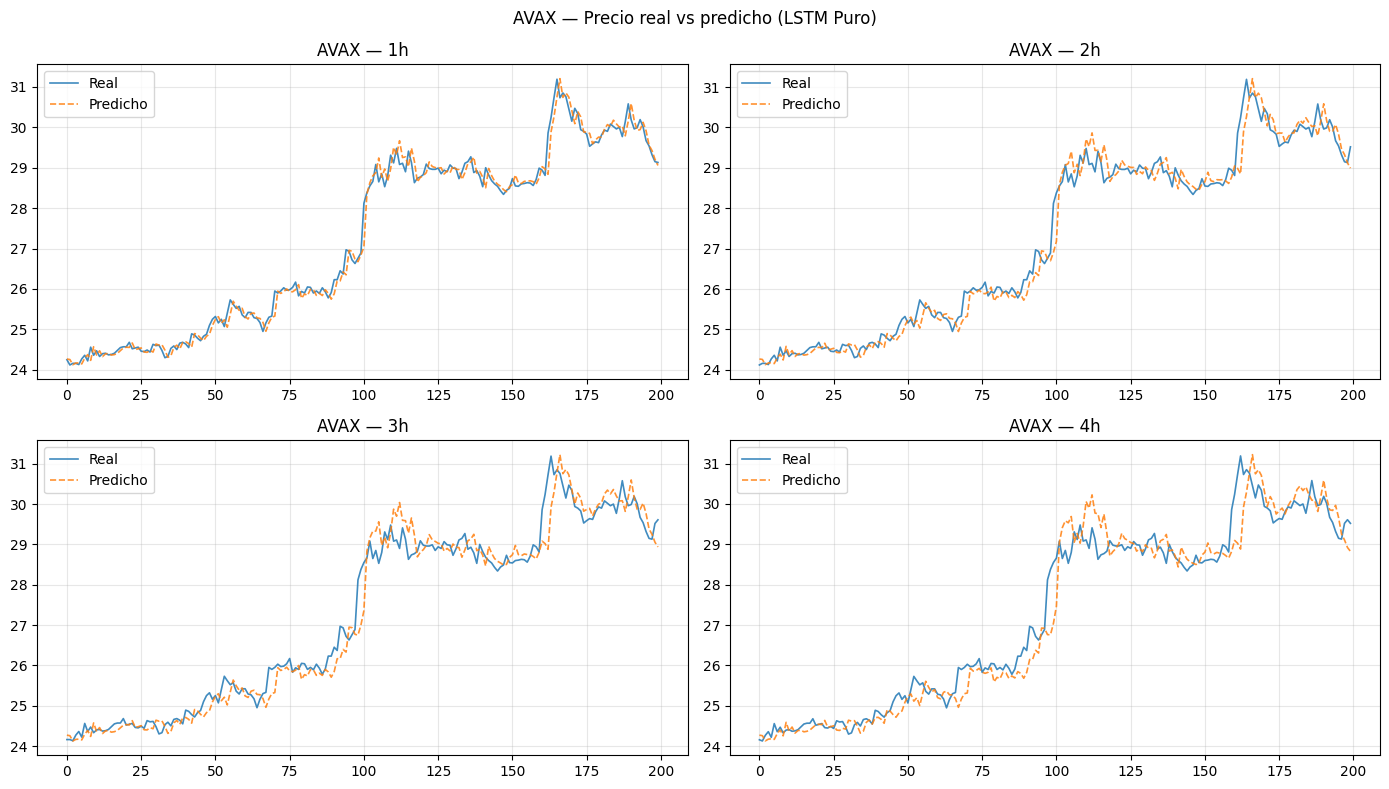

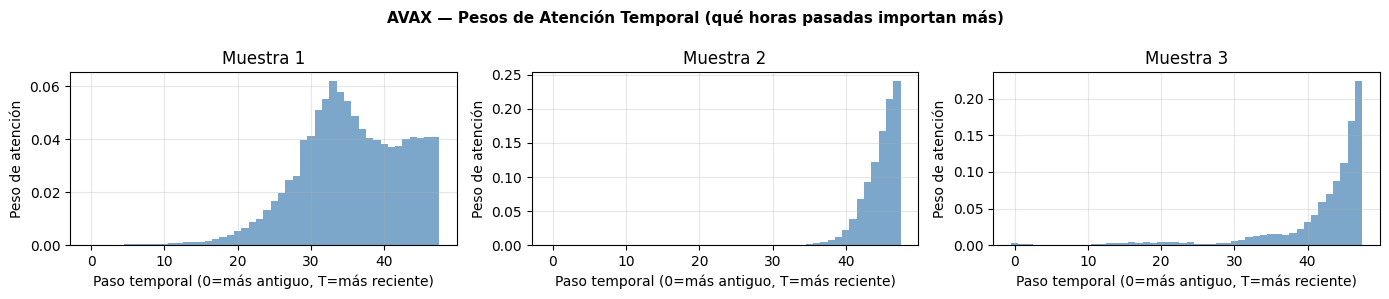

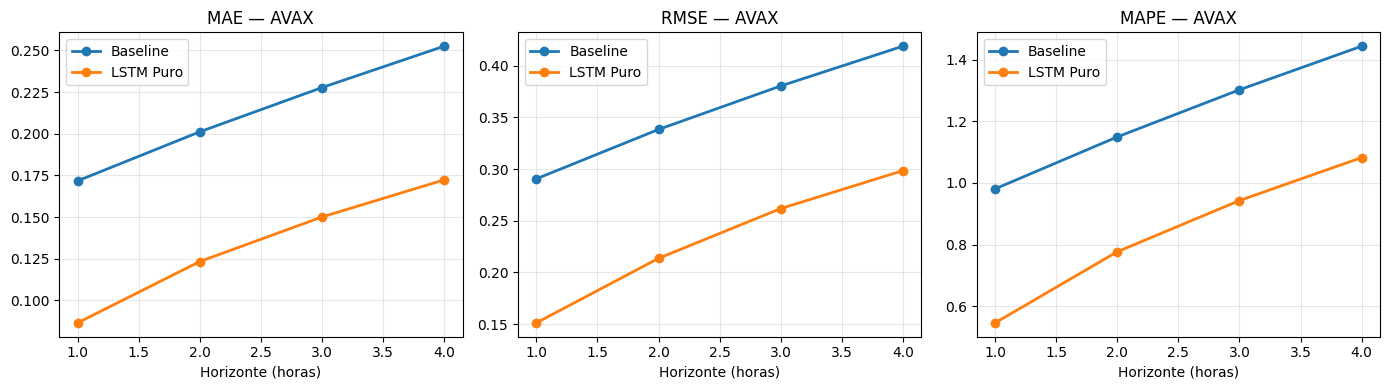



  WALK-FORWARD VALIDATION (métricas honestas)

  WALK-FORWARD VALIDATION — BTC (5 folds)

  Fold 1/5 | train: 41711 | val: 2606 | test: 2606
  Epoch   1/60 | Train 0.47517 | Val 0.30336
  Epoch  10/60 | Train 0.39127 | Val 0.26744
  Epoch  20/60 | Train 0.27188 | Val 0.25323
  ⏹ Early stopping epoch 27 (best val: 0.24852)
  Fold 1 → DirAcc_H1: 58.3% | DirAcc_H2: 61.2% | DirAcc_H3: 62.6% | DirAcc_H4: 63.3% | WinRate: 75.0%

  Fold 2/5 | train: 33891 | val: 2606 | test: 2606
  Epoch   1/60 | Train 0.50686 | Val 0.27432
  Epoch  10/60 | Train 0.41920 | Val 0.23823
  Epoch  20/60 | Train 0.28064 | Val 0.22141
  ⏹ Early stopping epoch 24 (best val: 0.21953)
  Fold 2 → DirAcc_H1: 57.6% | DirAcc_H2: 60.5% | DirAcc_H3: 61.7% | DirAcc_H4: 62.5% | WinRate: 82.1%

  Fold 3/5 | train: 26071 | val: 2606 | test: 2606
  Epoch   1/60 | Train 0.44174 | Val 0.20627
  Epoch  10/60 | Train 0.36809 | Val 0.17511
  Epoch  20/60 | Train 0.23714 | Val 0.17592
  ⏹ Early stopping epoch 25 (best val: 0.16441)


In [17]:
def save_artifacts(coin, model, feat_scaler, reg_scaler, feat_cols):
    torch.save(model.state_dict(), f"{WORK_DIR}/model_{coin}.pt")
    with open(f"{WORK_DIR}/scaler_{coin}.pkl", "wb") as f:
        pickle.dump({"feat_scaler": feat_scaler, "reg_scaler": reg_scaler,
                     "feat_cols": feat_cols, "n_features": len(feat_cols)}, f)
    print(f"  💾 model_{coin}.pt + scaler_{coin}.pkl guardados")

def load_artifacts(coin, cfg):
    model_path  = f"{MODELS_DIR}/model_{coin}.pt"
    scaler_path = f"{MODELS_DIR}/scaler_{coin}.pkl"
    if not os.path.exists(model_path) or not os.path.exists(scaler_path):
        return None
    try:
        with open(scaler_path, "rb") as f:
            artifacts = pickle.load(f)
        feat_cols = artifacts["feat_cols"]
        n_saved   = artifacts["n_features"]
        csv_path  = f"{cfg['data_dir']}/{coin}_{cfg['granularity']}.csv"
        df_cols   = pd.read_csv(csv_path, nrows=1).columns.tolist()
        feat_available = [c for c in feat_cols if c in df_cols]
        if len(feat_available) != n_saved:
            print(f"  ⚠ {coin}: features incompatibles → reentrenando")
            return None
        model = CryptoLSTM(n_saved, len(cfg["horizons"]), cfg).to(DEVICE)
        model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
        model.eval()
        print(f"  ✅ {coin}: modelo cargado ({n_saved} features)")
        return model, artifacts["feat_scaler"], artifacts["reg_scaler"], feat_cols
    except Exception as e:
        print(f"  ⚠ {coin}: error cargando ({e}) → reentrenando")
        return None

def run_pipeline(coin, cfg):
    print(f"\n{'='*55}")
    print(f"  {coin.upper()} | seq={cfg['seq_len']} lstm_h={cfg['lstm_hidden']} "
          f"layers={cfg['lstm_layers']} lr={cfg['learning_rate']:.2e}")
    print(f"{'='*55}")

    loaded = load_artifacts(coin, cfg)

    if loaded is not None:
        model, feat_scaler, reg_scaler, feat_cols = loaded
        path     = f"{cfg['data_dir']}/{coin}_{cfg['granularity']}.csv"
        df       = pd.read_csv(path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
        reg_cols = [f"target_ret_{h}" for h in cfg["horizons"]]
        df       = df[feat_cols + reg_cols].dropna()
        n        = len(df)
        test_df  = df.iloc[int(n*cfg["train_ratio"]) + int(n*cfg["val_ratio"]):]
        seq      = cfg["seq_len"]
        X_te  = feat_scaler.transform(test_df[feat_cols].values).astype(np.float32)
        yr_te = reg_scaler.transform(test_df[reg_cols].values).astype(np.float32)
        Xs, yrs = [], []
        for i in range(seq, len(X_te)):
            Xs.append(X_te[i-seq:i]); yrs.append(yr_te[i])
        X_te  = np.array(Xs, dtype=np.float32)
        yr_te = np.array(yrs, dtype=np.float32)
        close_test = test_df["close"].values[seq:]
        test_ds     = CryptoDataset(X_te, yr_te)
        test_loader = DataLoader(test_ds, batch_size=cfg["batch_size"], shuffle=False,
                                 num_workers=2, pin_memory=(DEVICE.type=="cuda"),
                                 persistent_workers=True)
        history = None
    else:
        datasets, feat_scaler, reg_scaler, close_test, feat_cols = load_and_preprocess(coin, cfg)
        n_features  = datasets["train"].X.shape[2]
        loaders     = make_loaders(datasets, cfg)
        test_loader = loaders["test"]
        model       = CryptoLSTM(n_features, len(cfg["horizons"]), cfg).to(DEVICE)
        n_p         = count_params(model)
        print(f"  Parámetros: {n_p:,} | Features: {n_features}")
        history = train_model(model, loaders, cfg, coin)
        plot_history(history, coin)
        save_artifacts(coin, model, feat_scaler, reg_scaler, feat_cols)

    lstm_res, reg_pred, reg_true = evaluate_model(
        model, test_loader, close_test, reg_scaler, cfg["horizons"], coin
    )
    if history is not None:
        plot_preds(reg_pred, reg_true, close_test, coin, cfg["horizons"])

    # Visualizar pesos de atención
    plot_attention_weights(model, test_loader, coin)

    raw_path = f"{cfg['data_dir']}/{coin}_1h_raw.csv"
    if not os.path.exists(raw_path):
        raw_path = f"{cfg['raw_dir']}/{coin}_1h_raw.csv"
    df_raw   = pd.read_csv(raw_path, parse_dates=["timestamp"])
    n_skip   = int(len(df_raw)*cfg["train_ratio"]) + int(len(df_raw)*cfg["val_ratio"])
    base_res = moving_average_baseline(df_raw.iloc[n_skip:].copy(), cfg["horizons"])
    plot_comparison(lstm_res, base_res, coin)

    return {"model": model, "feat_scaler": feat_scaler, "reg_scaler": reg_scaler,
            "lstm_res": lstm_res, "base_res": base_res, "close_test": close_test,
            "cfg": cfg, "feat_cols": feat_cols, "reg_pred": reg_pred, "reg_true": reg_true}


all_results = {}
for coin in BASE_CONFIG["coins"]:
    cfg = BEST_CONFIGS.get(coin, BASE_CONFIG)
    try:
        all_results[coin] = run_pipeline(coin, cfg)
    except FileNotFoundError as e:
        print(f"  ⚠ {coin}: {e}")
    except Exception:
        import traceback; traceback.print_exc()

if all_results:
    print("\n\n" + "="*60)
    print("  WALK-FORWARD VALIDATION (métricas honestas)")
    print("="*60)
    wf_results = run_all_wf(BASE_CONFIG["coins"], BEST_CONFIGS, n_folds=5)

bt_results = {}
for coin, res in all_results.items():
    bt_results[coin] = run_backtest_fixed(coin, res, BEST_CONFIGS[coin])

    for coin, res in all_results.items():
        reg_pred = res["reg_pred"]
        reg_true = res["reg_true"]
        dacc     = compute_diracc_full(reg_pred, reg_true)
        print_honest_metrics(coin, dacc, bt_results.get(coin))
    

# 🔮 Inferencia con Intervalos de Confianza

In [18]:
def get_recent_data(coin, cfg):
    seq_len = cfg["seq_len"]; buffer = 60; symbol = COINS_MAP[coin]
    df_1h = download_recent(symbol, "1h", seq_len + buffer)
    if df_1h is None:
        COIN_IDS = {"BTC":"bitcoin","ETH":"ethereum","SOL":"solana","XRP":"ripple","AVAX":"avalanche-2"}
        days = math.ceil((seq_len + buffer) / 24) + 2
        resp = requests.get(f"https://api.coingecko.com/api/v3/coins/{COIN_IDS[coin]}/ohlc",
                            params={"vs_currency":"usd","days":days}, timeout=20)
        rows = [{"timestamp": pd.to_datetime(c[0], unit="ms", utc=True),
                 "open":float(c[1]),"high":float(c[2]),"low":float(c[3]),
                 "close":float(c[4]),"volume":0.0} for c in resp.json()]
        df_1h = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
    df_1h["coin"] = coin
    df = add_features_1h(df_1h)
    fg_rec = download_fear_greed(limit=10)
    df = merge_external(df, fg_rec)
    df_4h = download_recent(symbol, "4h", 50)
    df_1d = download_recent(symbol, "1d", 30)
    if df_4h is not None and df_1d is not None:
        df = merge_multitf(df, df_4h, df_1d)
    else:
        for col in ["rsi_4h","macd_4h","return_4h","vol_ratio_4h","rsi_1d","macd_1d","return_1d"]:
            df[col] = 0.0
    return df.dropna().reset_index(drop=True)

def predict_next(coin, result):
    model       = result["model"]
    feat_scaler = result["feat_scaler"]
    reg_scaler  = result["reg_scaler"]
    cfg         = result["cfg"]
    feat_cols   = result["feat_cols"]
    seq_len     = cfg["seq_len"]
    mape        = MAPE_HISTORICO.get(coin, 0.01)

    df_recent  = get_recent_data(coin, cfg)
    if len(df_recent) < seq_len:
        raise ValueError(f"Datos insuficientes: {len(df_recent)} < {seq_len}")

    available  = [c for c in feat_cols if c in df_recent.columns]
    X_raw      = df_recent[available].iloc[-seq_len:].values.astype(np.float32)
    X_tensor   = torch.tensor(feat_scaler.transform(X_raw)[np.newaxis], dtype=torch.float32).to(DEVICE)
    last_close = float(df_recent["close"].iloc[-1])
    last_time  = df_recent["timestamp"].iloc[-1]

    model.eval()
    with torch.no_grad():
        reg_vals = reg_scaler.inverse_transform(model(X_tensor).cpu().numpy())[0]

    preds = {}
    for i, h in enumerate(cfg["horizons"]):
        ret    = float(reg_vals[i])
        price  = round(last_close * (1 + ret), 4)
        margen = price * mape
        preds[f"{h}h"] = {
            "precio_estimado":    price,
            "precio_min":         round(price - margen, 4),
            "precio_max":         round(price + margen, 4),
            "retorno_esperado_%": round(ret * 100, 3),
            "direccion":          "↑ SUBE" if ret > 0 else "↓ BAJA",
        }
    return last_close, last_time, preds

print("=" * 62)
print("  PREDICCIONES EN TIEMPO REAL — LSTM")
print("=" * 62)
all_predictions = {}
for coin, res in all_results.items():
    try:
        last_close, last_time, preds = predict_next(coin, res)
        all_predictions[coin] = preds
        print(f"\n  {coin} | Cierre: {last_close:.4f} USD | {last_time}")
        print(f"  {'─'*58}")
        print(f"  {'Horizonte':>10} | {'Estimado':>12} | {'Min':>12} | {'Max':>12} | Dir")
        print(f"  {'─'*10}-+-{'─'*12}-+-{'─'*12}-+-{'─'*12}-+----")
        for h, p in preds.items():
            arrow = "↑" if p["direccion"] == "↑ SUBE" else "↓"
            print(f"  {h:>10} | {p['precio_estimado']:>12.4f} | "
                  f"{p['precio_min']:>12.4f} | {p['precio_max']:>12.4f} | {arrow} "
                  f"{p['retorno_esperado_%']:+.3f}%")
    except Exception as e:
        print(f"  ✗ {coin}: {e}")
        import traceback; traceback.print_exc()

  PREDICCIONES EN TIEMPO REAL — LSTM

  BTC | Cierre: 80855.8900 USD | 2026-05-05 11:00:00+00:00
  ──────────────────────────────────────────────────────────
   Horizonte |     Estimado |          Min |          Max | Dir
  ──────────-+-────────────-+-────────────-+-────────────-+----
          1h |   80836.2177 |   80391.6185 |   81280.8169 | ↓ -0.024%
          2h |   80833.1340 |   80388.5518 |   81277.7162 | ↓ -0.028%
          3h |   80824.8884 |   80380.3515 |   81269.4253 | ↓ -0.038%
          4h |   80814.0009 |   80369.5239 |   81258.4779 | ↓ -0.052%

  ETH | Cierre: 2377.8200 USD | 2026-05-05 11:00:00+00:00
  ──────────────────────────────────────────────────────────
   Horizonte |     Estimado |          Min |          Max | Dir
  ──────────-+-────────────-+-────────────-+-────────────-+----
          1h |    2378.1835 |    2356.5420 |    2399.8250 | ↑ +0.015%
          2h |    2379.2766 |    2357.6252 |    2400.9280 | ↑ +0.061%
          3h |    2381.0195 |    2359.3522 |  

# Resumen final

In [19]:
def resumen_final_honesto(all_results: dict, bt_results: dict, wf_results: dict):
    """
    Imprime un resumen final con métricas en el orden correcto de importancia:
    1. DirAcc walk-forward (lo más honesto)
    2. DirAcc test fijo (sin filtro)
    3. Backtesting con umbral calibrado en train
    """
    print("\n" + "="*65)
    print("  RESUMEN FINAL HONESTO — Orden de métricas por fiabilidad")
    print("="*65)
    print("""
  JERARQUÍA DE MÉTRICAS (de más a menos fiable):
  ─────────────────────────────────────────────────────────────
  1. DirAcc walk-forward  → más honesta, varianza entre folds
  2. DirAcc test fijo     → sin filtros, señal real del modelo
  3. Win rate backtest    → con umbral calibrado en TRAIN
  4. Retorno total        → depende del período (sesgo de mercado)
  ─────────────────────────────────────────────────────────────
    """)
 
    for coin in all_results.keys():
        res = all_results[coin]
        print(f"\n  {coin}")
        print(f"  {'─'*55}")
 
        # 1. DirAcc walk-forward
        if coin in wf_results and not wf_results[coin].empty:
            df_wf = wf_results[coin]
            for h in BASE_CONFIG["horizons"]:
                col  = f"DirAcc_H{h}"
                if col in df_wf.columns:
                    m, s = df_wf[col].mean(), df_wf[col].std()
                    flag = "✅" if m > 0.52 else "⚠"
                    print(f"  [WF] DirAcc H{h}: {m*100:.1f}% ± {s*100:.1f}%  {flag}")
 
        # 2. DirAcc test fijo
        reg_pred = res["reg_pred"]
        reg_true = res["reg_true"]
        for i, h in enumerate(BASE_CONFIG["horizons"]):
            dacc = float(np.mean(np.sign(reg_pred[:, i]) == np.sign(reg_true[:, i])))
            flag = "✅" if dacc > 0.52 else "⚠"
            print(f"  [TEST] DirAcc H{h}: {dacc*100:.1f}%  {flag}")
 
        # 3. Backtesting
        bt = bt_results.get(coin)
        if bt:
            pf = bt.get("profit_factor", compute_profit_factor(bt["retornos"]))
            print(f"  [BT] Win rate: {bt['win_rate']*100:.1f}%  "
                  f"PF: {pf:.2f}  Trades: {bt['n_trades']}")
            if bt["n_trades"] < 30:
                print(f"  ⚠ Pocos trades — no estadísticamente significativo")
 
    print("\n" + "="*65)
    print("  INTERPRETACIÓN")
    print("="*65)
    print("""
          DirAcc > 54% en walk-forward  → habilidad real demostrada
          DirAcc 52–54%                 → marginal, necesita más validación
          DirAcc < 52%                  → el modelo no aporta señal
          Profit Factor > 1.5           → sistema con ventaja neta
          Win rate sin PF               → no informativo por sí solo
    """)
print(resumen_final_honesto(all_results, bt_results, wf_results))


  RESUMEN FINAL HONESTO — Orden de métricas por fiabilidad

  JERARQUÍA DE MÉTRICAS (de más a menos fiable):
  ─────────────────────────────────────────────────────────────
  1. DirAcc walk-forward  → más honesta, varianza entre folds
  2. DirAcc test fijo     → sin filtros, señal real del modelo
  3. Win rate backtest    → con umbral calibrado en TRAIN
  4. Retorno total        → depende del período (sesgo de mercado)
  ─────────────────────────────────────────────────────────────
    

  BTC
  ───────────────────────────────────────────────────────
  [WF] DirAcc H1: 56.9% ± 1.3%  ✅
  [WF] DirAcc H2: 59.6% ± 2.0%  ✅
  [WF] DirAcc H3: 61.0% ± 1.7%  ✅
  [WF] DirAcc H4: 62.0% ± 1.5%  ✅
  [TEST] DirAcc H1: 59.0%  ✅
  [TEST] DirAcc H2: 61.2%  ✅
  [TEST] DirAcc H3: 62.0%  ✅
  [TEST] DirAcc H4: 64.0%  ✅
  [BT] Win rate: 72.2%  PF: 6.76  Trades: 550

  ETH
  ───────────────────────────────────────────────────────
  [WF] DirAcc H1: 57.4% ± 2.7%  ✅
  [WF] DirAcc H2: 60.7% ± 2.5%  ✅
  [WF] DirA